In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# load dataset
df = pd.read_csv("Traffic_Crashes_-_Crashes_20250920.csv")
df.head()

,CRASH_RECORD_ID,CRASH_DATE_EST_I,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,...,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
0,6e01f9a196d538a9966e07b77571aa2c16ed0934d70d6a...,NaN,09/20/2025 02:12:00 AM,35,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,NOT DIVIDED,...,0.0,0.0,1.0,0.0,2,7,9,42.022660,-87.676647,POINT (-87.67664723812 42.022660268078)
1,58611df156f261acca8dbc3f4d52708c77ab3cd6e50b7d...,Y,09/20/2025 01:05:00 AM,25,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE OPPOSITE DIRECTION,DIVIDED - W/MEDIAN (NOT RAISED),...,0.0,0.0,2.0,0.0,1,7,9,41.773080,-87.615393,POINT (-87.615392621573 41.773080310407)
2,72cab98be7a0bc8fd2878a44caa73db237b3c1915d8bf5...,NaN,09/20/2025 01:00:00 AM,35,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",OTHER OBJECT,NOT DIVIDED,...,0.0,0.0,2.0,0.0,1,7,9,41.799166,-87.723186,POINT (-87.723186126595 41.7991664566)
3,e248ec4673b109000e7d73cb81a2d7cebf23a6fa127f5d...,NaN,09/20/2025 12:03:00 AM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,"DARKNESS, LIGHTED ROAD",HEAD ON,DIVIDED - W/MEDIAN (NOT RAISED),...,0.0,0.0,8.0,0.0,0,7,9,41.807530,-87.743297,POINT (-87.743296821242 41.807530372894)
4,8f692b1a9bd229f17a36d4a4db99a026223c4c98e66e70...,NaN,09/19/2025 11:30:00 PM,40,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,DIVIDED - W/MEDIAN BARRIER,...,0.0,0.0,1.0,0.0,23,6,9,41.845343,-87.610998,POINT (-87.610998044537 41.845342867304)


In [3]:
# check the shape of our dataset
print(f"This dataset has {df.shape[0]} rows and {df.shape[1]} columns")

This dataset has 986133 rows and 48 columns


In [4]:
# what are the datasets columns
df.columns

Index(['CRASH_RECORD_ID', 'CRASH_DATE_EST_I', 'CRASH_DATE',
       'POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION',
       'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE',
       'TRAFFICWAY_TYPE', 'LANE_CNT', 'ALIGNMENT', 'ROADWAY_SURFACE_COND',
       'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'INTERSECTION_RELATED_I',
       'NOT_RIGHT_OF_WAY_I', 'HIT_AND_RUN_I', 'DAMAGE', 'DATE_POLICE_NOTIFIED',
       'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_NO',
       'STREET_DIRECTION', 'STREET_NAME', 'BEAT_OF_OCCURRENCE',
       'PHOTOS_TAKEN_I', 'STATEMENTS_TAKEN_I', 'DOORING_I', 'WORK_ZONE_I',
       'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I', 'NUM_UNITS',
       'MOST_SEVERE_INJURY', 'INJURIES_TOTAL', 'INJURIES_FATAL',
       'INJURIES_INCAPACITATING', 'INJURIES_NON_INCAPACITATING',
       'INJURIES_REPORTED_NOT_EVIDENT', 'INJURIES_NO_INDICATION',
       'INJURIES_UNKNOWN', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH',
       'LATITUDE', 

**Observation:**

Looks like the data columns may need to be changed to lower case for easier data manipulation


In [6]:
# change columns to lower case
df.columns = df.columns.str.lower()
df.columns

Index(['crash_record_id', 'crash_date_est_i', 'crash_date',
       'posted_speed_limit', 'traffic_control_device', 'device_condition',
       'weather_condition', 'lighting_condition', 'first_crash_type',
       'trafficway_type', 'lane_cnt', 'alignment', 'roadway_surface_cond',
       'road_defect', 'report_type', 'crash_type', 'intersection_related_i',
       'not_right_of_way_i', 'hit_and_run_i', 'damage', 'date_police_notified',
       'prim_contributory_cause', 'sec_contributory_cause', 'street_no',
       'street_direction', 'street_name', 'beat_of_occurrence',
       'photos_taken_i', 'statements_taken_i', 'dooring_i', 'work_zone_i',
       'work_zone_type', 'workers_present_i', 'num_units',
       'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication',
       'injuries_unknown', 'crash_hour', 'crash_day_of_week', 'crash_month',
       'latitude', 

In [7]:
# check each columns information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986133 entries, 0 to 986132
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_record_id                986133 non-null  object 
 1   crash_date_est_i               71838 non-null   object 
 2   crash_date                     986133 non-null  object 
 3   posted_speed_limit             986133 non-null  int64  
 4   traffic_control_device         986133 non-null  object 
 5   device_condition               986133 non-null  object 
 6   weather_condition              986133 non-null  object 
 7   lighting_condition             986133 non-null  object 
 8   first_crash_type               986133 non-null  object 
 9   trafficway_type                986133 non-null  object 
 10  lane_cnt                       199029 non-null  object 
 11  alignment                      986133 non-null  object 
 12  roadway_surface_cond          

In [8]:
# check columns unique values
df.nunique()

crash_record_id                  986133
crash_date_est_i                      2
crash_date                       650971
posted_speed_limit                   46
traffic_control_device               19
device_condition                      8
weather_condition                    12
lighting_condition                    6
first_crash_type                     18
trafficway_type                      20
lane_cnt                             61
alignment                             6
roadway_surface_cond                  7
road_defect                           7
report_type                           3
crash_type                            2
intersection_related_i                2
not_right_of_way_i                    2
hit_and_run_i                         2
damage                                3
date_police_notified             746563
prim_contributory_cause              40
sec_contributory_cause               40
street_no                         11934
street_direction                      4


In [9]:
# check missingness of data
df.isnull().sum()

crash_record_id                       0
crash_date_est_i                 914295
crash_date                            0
posted_speed_limit                    0
traffic_control_device                0
device_condition                      0
weather_condition                     0
lighting_condition                    0
first_crash_type                      0
trafficway_type                       0
lane_cnt                         787104
alignment                             0
roadway_surface_cond                  0
road_defect                           0
report_type                       32318
crash_type                            0
intersection_related_i           759489
not_right_of_way_i               941722
hit_and_run_i                    676725
damage                                0
date_police_notified                  0
prim_contributory_cause               0
sec_contributory_cause                0
street_no                             0
street_direction                      4


**Observation**

From this we can see columns such as `CRASH_DATE_EST_I`, `LANE_CNT`, `INTERSECTION_RELATED_I`, `NOT_RIGHT_OF_WAY_I` among others have a large number of missing values. We may be most likely forced to drop them because they will not offer us much information.

In [11]:
num_cols = df.select_dtypes(include="number")
num_cols.columns.tolist()

['posted_speed_limit',
 'street_no',
 'beat_of_occurrence',
 'num_units',
 'injuries_total',
 'injuries_fatal',
 'injuries_incapacitating',
 'injuries_non_incapacitating',
 'injuries_reported_not_evident',
 'injuries_no_indication',
 'injuries_unknown',
 'crash_hour',
 'crash_day_of_week',
 'crash_month',
 'latitude',
 'longitude']

In [12]:
# check numerical data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
posted_speed_limit,986133.0,28.423503,6.060047,0.000000,30.000000,30.000000,30.000000,99.00000
street_no,986133.0,3686.408691,2873.418010,0.000000,1257.000000,3201.000000,5555.000000,451100.00000
beat_of_occurrence,986128.0,1247.382479,704.688551,111.000000,722.000000,1213.000000,1822.000000,6100.00000
num_units,986133.0,2.035136,0.449867,1.000000,2.000000,2.000000,2.000000,18.00000
injuries_total,983994.0,0.197298,0.576793,0.000000,0.000000,0.000000,0.000000,21.00000
injuries_fatal,983994.0,0.001155,0.036871,0.000000,0.000000,0.000000,0.000000,4.00000
injuries_incapacitating,983994.0,0.019362,0.162867,0.000000,0.000000,0.000000,0.000000,10.00000
injuries_non_incapacitating,983994.0,0.109727,0.426473,0.000000,0.000000,0.000000,0.000000,21.00000
injuries_reported_not_evident,983994.0,0.067053,0.333686,0.000000,0.000000,0.000000,0.000000,19.00000
injuries_no_indication,983994.0,1.997930,1.155567,0.000000,1.000000,2.000000,2.000000,61.00000


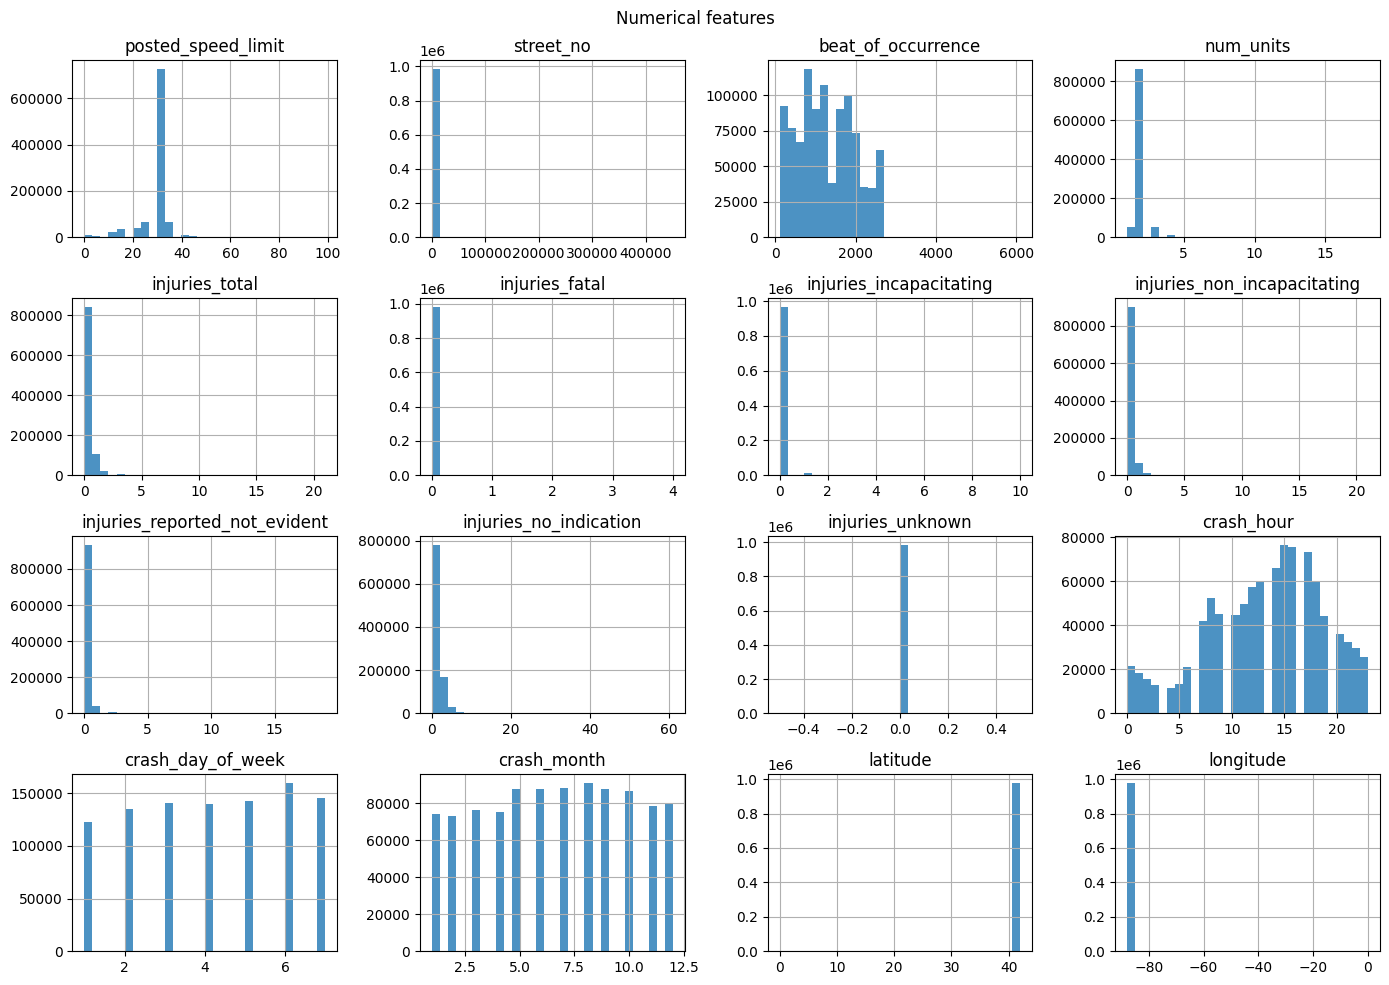

In [13]:
# Lets get a visualisation for the numerical features
df.hist(figsize=(14,10), bins=30, alpha=0.8)
plt.suptitle("Numerical features")
plt.tight_layout()
plt.show()

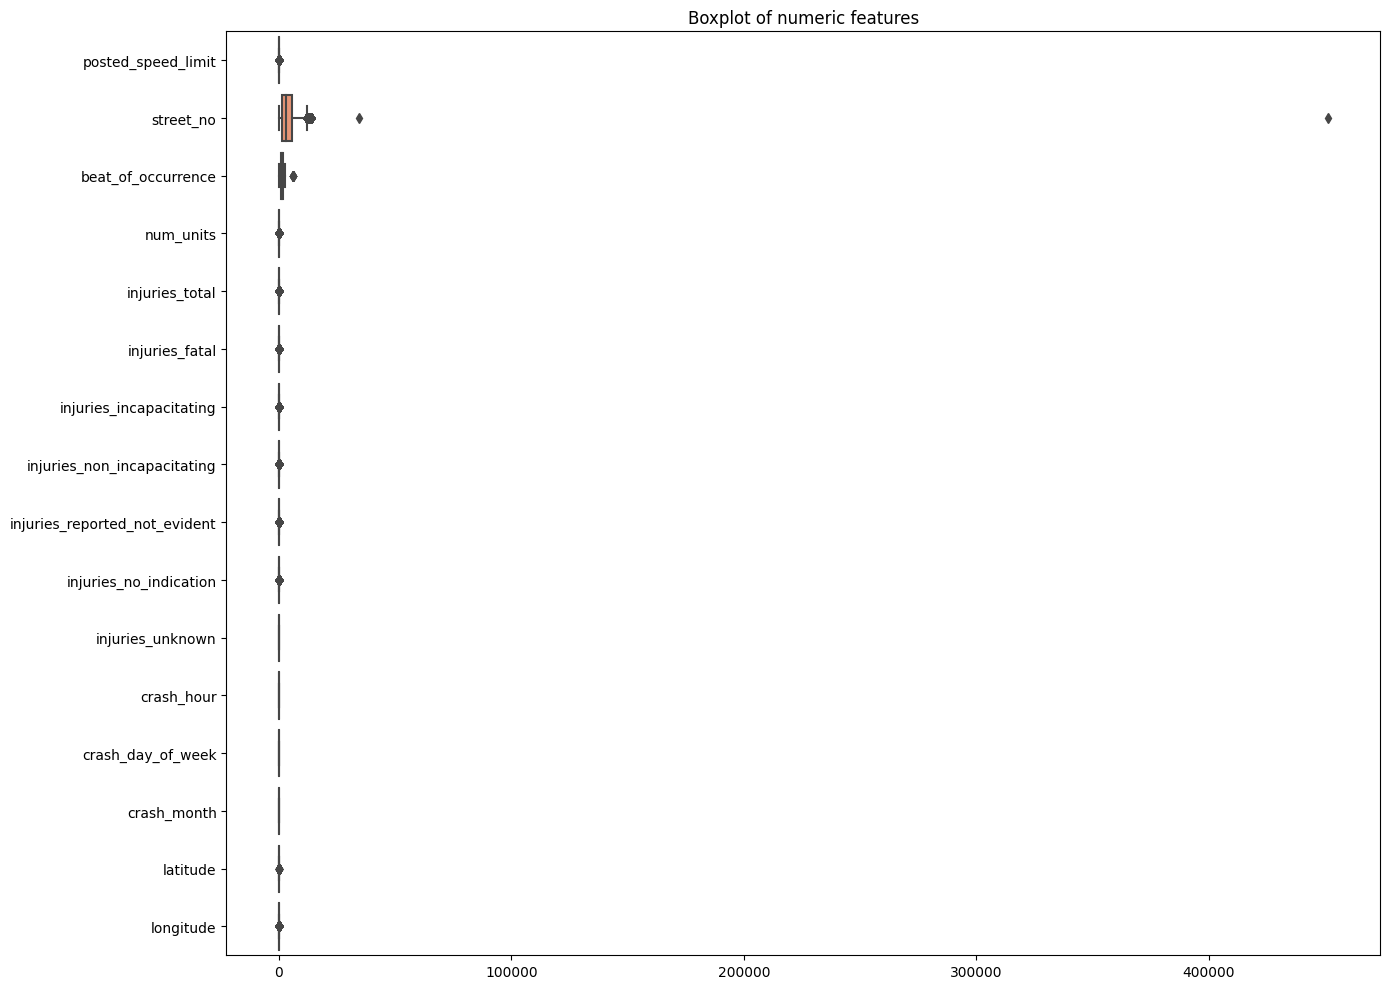

In [14]:
# check for outliers
plt.figure(figsize=(14,10))
sns.boxplot(data=num_cols, orient="h")
plt.title("Boxplot of numeric features")
plt.tight_layout()
plt.show()

In [15]:
# check categorical variables
df.describe(include="O").T

,count,unique,top,freq
crash_record_id,986133,986133,6e01f9a196d538a9966e07b77571aa2c16ed0934d70d6a...,1
crash_date_est_i,71838,2,Y,62652
crash_date,986133,650971,02/06/2025 08:00:00 AM,37
traffic_control_device,986133,19,NO CONTROLS,555971
device_condition,986133,8,NO CONTROLS,562957
weather_condition,986133,12,CLEAR,775998
lighting_condition,986133,6,DAYLIGHT,634616
first_crash_type,986133,18,PARKED MOTOR VEHICLE,227705
trafficway_type,986133,20,NOT DIVIDED,422109
lane_cnt,199029.0,61.0,2.0,73424.0


In [16]:
# check how long our data spans
df["crash_date"] = pd.to_datetime(df["crash_date"])

print(f"This dataset records our first incident on {df['crash_date'].min().date()} all the way to {df['crash_date'].max().date()}")

# records by year
print("\n")
print(df['crash_date'].dt.year.value_counts().sort_index())

This dataset records our first incident on 2013-03-03 all the way to 2025-09-20


2013         2
2014         6
2015      9831
2016     44297
2017     83786
2018    118951
2019    117764
2020     92095
2021    108766
2022    108411
2023    110752
2024    112050
2025     79422
Name: crash_date, dtype: int64


**Observation**

We can see that 2013 and 2014 have 2 and 6 respectively which may not an accurate indication of the events of those years. The rest of the years numbers seem relatively highly balanced

In [18]:
# check duplicates
duplicates = df.duplicated().sum()
print(duplicates)

# missingness of data
missing_cols = df.isnull().sum()
missing_percentage = (missing_cols/len(df))*100
# put into data frame
missing_info = pd.DataFrame({'Missing Values': missing_cols, 'Percentage': missing_percentage})
print("\nMissing values and percentage:\n", missing_info[missing_info['Percentage'] > 0.000000])

0

Missing values and percentage:
                                Missing Values  Percentage
crash_date_est_i                       914295   92.715181
lane_cnt                               787104   79.817225
report_type                             32318    3.277246
intersection_related_i                 759489   77.016893
not_right_of_way_i                     941722   95.496449
hit_and_run_i                          676725   68.624111
street_direction                            4    0.000406
street_name                                 1    0.000101
beat_of_occurrence                          5    0.000507
photos_taken_i                         972217   98.588831
statements_taken_i                     962829   97.636830
dooring_i                              982986   99.680875
work_zone_i                            980741   99.453218
work_zone_type                         982009   99.581801
workers_present_i                      984750   99.859755
most_severe_injury                   

## Data Cleaning and Preparation

In [20]:
# inspect columns
df.columns

Index(['crash_record_id', 'crash_date_est_i', 'crash_date',
       'posted_speed_limit', 'traffic_control_device', 'device_condition',
       'weather_condition', 'lighting_condition', 'first_crash_type',
       'trafficway_type', 'lane_cnt', 'alignment', 'roadway_surface_cond',
       'road_defect', 'report_type', 'crash_type', 'intersection_related_i',
       'not_right_of_way_i', 'hit_and_run_i', 'damage', 'date_police_notified',
       'prim_contributory_cause', 'sec_contributory_cause', 'street_no',
       'street_direction', 'street_name', 'beat_of_occurrence',
       'photos_taken_i', 'statements_taken_i', 'dooring_i', 'work_zone_i',
       'work_zone_type', 'workers_present_i', 'num_units',
       'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication',
       'injuries_unknown', 'crash_hour', 'crash_day_of_week', 'crash_month',
       'latitude', 

| Column                | Description |
|------------------------------------|---------------|
| crash_record_id | This number can be used to link to the same crash in the Vehicles and People datasets. This number also serves as a unique ID in this dataset | 
| crash_date_est_i | Crash date estimated by desk officer or reporting party (only used in cases where crash is reported at police station days after the crash) |  
| crash_date | Date and time of crash as entered by the reporting officer |  
| posted_speed_limit | Posted speed limit, as determined by reporting officer |
| traffic_control_device | Traffic control device present at crash location, as determined by reporting officer |  
| device_condition | Condition of traffic control device, as determined by reporting officer | 
| weather_condition | Weather condition at time of crash, as determined by reporting office | 
| lighting_condition | Light condition at time of crash, as determined by reporting office |  
| first_crash_type | Type of first collision in crash |  
| trafficway_type | Trafficway type, as determined by reporting officer |
| lane_cnt | Total number of through lanes in either direction, excluding turn lanes, as determined by reporting officer (0 = intersection) |  
| alignment | Street alignment at crash location, as determined by reporting officer | 
| roadway_surface_cond | Road surface condition, as determined by reporting officer | 
| road_defect | Road defects, as determined by reporting officer |  
| report_type | Administrative report type (at scene, at desk, amended) |  
| crash_type | A general severity classification for the crash. Can be either Injury and/or Tow Due to Crash or No Injury / Drive Away |
| intersection_related_i | A field observation by the police officer whether an intersection played a role in the crash. Does not represent whether or not the crash occurred within the intersection |  
| not_right_of_way_i | 	Whether the crash begun or first contact was made outside of the public right-of-way. | 
| hit_and_run_i | Crash did/did not involve a driver who caused the crash and fled the scene without exchanging information and/or rendering aid | 
| damage | A field observation of estimated damage. |  
| date_police_notified | Calendar date on which police were notified of the crash |  
| prim_contributory_cause | The factor which was most significant in causing the crash, as determined by officer judgment |
| sec_contributory_cause | The factor which was second most significant in causing the crash, as determined by officer judgment |  
| street_no | Street address number of crash location, as determined by reporting officer | 
| street_direction | Street address direction (N,E,S,W) of crash location, as determined by reporting officer | 
| street_name | Street address name of crash location, as determined by reporting officer |  
| beat_of_occurrence | Chicago Police Department Beat ID. Boundaries available at https://data.cityofchicago.org/d/aerh-rz74 |  
| photos_taken_i | Whether the Chicago Police Department took photos at the location of the crash |
| statements_taken_i | Whether statements were taken from unit(s) involved in crash |  
| dooring_i | Whether crash involved a motor vehicle occupant opening a door into the travel path of a bicyclist, causing a crash | 
| work_zone_i | Whether the crash occurred in an active work zone | 
| work_zone_type | The type of work zone, if any |  
| workers_present_i | Whether construction workers were present in an active work zone at crash location |  
| num_units | Number of units involved in the crash. A unit can be a motor vehicle, a pedestrian, a bicyclist, or another non-passenger roadway user. Each unit represents a mode of traffic with an independent trajectory. |
| most_severe_injury | Most severe injury sustained by any person involved in the crash |  
| injuries_total | Total persons sustaining fatal, incapacitating, non-incapacitating, and possible injuries as determined by the reporting officer | 
| injuries_fatal | Total persons sustaining fatal injuries in the crash |  
| injuries_incapacitating | Total persons sustaining incapacitating/serious injuries in the crash as determined by the reporting officer.  | 
| injuries_non_incapacitating | Total persons sustaining non-incapacitating injuries in the crash as determined by the reporting officer. | 
| injuries_reported_not_evident | Total persons sustaining possible injuries in the crash as determined by the reporting officer. Includes momentary unconsciousness, claims of injuries not evident, limping, complaint of pain, nausea, and hysteria. | 
| injuries_no_indication | Total persons sustaining no injuries in the crash as determined by the reporting officer |  
| injuries_unknown | Total persons for whom injuries sustained, if any, are unknown |
| crash_hour | The hour of the day component of CRASH_DATE. |  
| crash_day_of_week | The day of the week component of CRASH_DATE. Sunday=1 | 
| crash_month | The month component of CRASH_DATE. | 
| latitude | The latitude of the crash location, as determined by reporting officer, as derived from the reported address of crash |  
| longitude | The longitude of the crash location, as determined by reporting officer, as derived from the reported address of crash |  
| location  |  The crash location, as determined by reporting officer, as derived from the reported address of crash, in a column type that allows for mapping and other geographic analysis in the data portal software |

In [22]:
# First lets drop the columns which dont give us much information
# These include columns with high null values
col_drop = missing_info[missing_info['Percentage'] > 67]
col_drop.index

Index(['crash_date_est_i', 'lane_cnt', 'intersection_related_i',
       'not_right_of_way_i', 'hit_and_run_i', 'photos_taken_i',
       'statements_taken_i', 'dooring_i', 'work_zone_i', 'work_zone_type',
       'workers_present_i'],
      dtype='object')

In [23]:
# drop columns
to_drop = col_drop.index

df.drop(to_drop, axis=1, inplace=True)

In [24]:
# inspecting columns
print(f"Number of unique values:  {df['posted_speed_limit'].nunique()}")
print("\n")
print(f"Unique Values: \n {df['posted_speed_limit'].unique()}")
print("\n")
print(df['posted_speed_limit'].value_counts())

Number of unique values:  46


Unique Values: 
 [35 25 30 40 55 20 15 10 45  5 65  0 50 60 39  3 12 32 26  2 22 70 24 14
 31 23 16 33  7 18 36 34 46  9  1  8 29 11 44 62  4 38 49  6 63 99]


30    727121
25     64135
35     63941
20     41486
15     35059
10     23403
40      9470
0       7736
45      6446
5       5235
55       960
50       299
3        240
39       100
9         96
99        66
60        58
1         41
24        39
2         33
65        21
32        21
34        16
26        14
33        14
11        11
36         8
70         8
6          7
12         6
7          6
14         6
22         5
18         4
23         3
29         3
31         3
16         2
8          2
4          2
38         2
46         1
44         1
62         1
49         1
63         1
Name: posted_speed_limit, dtype: int64


**Observation**

Posted speed limit of 0 could mean that there is no speed limit at the point of accident or maybe a freak accident that happened with stationary cars in a parking lot

In [26]:
# inspect control devices
print(f"Number of unique values:  {df['traffic_control_device'].nunique()}")
print(f" \n Unique Values: \n {df['traffic_control_device'].unique()}")

print(f"\n Number of unique values:  {df['device_condition'].nunique()}")
print(f" \n Unique Values: \n {df['device_condition'].unique()}")

Number of unique values:  19
 
 Unique Values: 
 ['NO CONTROLS' 'TRAFFIC SIGNAL' 'UNKNOWN' 'STOP SIGN/FLASHER' 'OTHER'
 'PEDESTRIAN CROSSING SIGN' 'YIELD' 'RAILROAD CROSSING GATE'
 'OTHER REG. SIGN' 'DELINEATORS' 'OTHER WARNING SIGN'
 'FLASHING CONTROL SIGNAL' 'SCHOOL ZONE' 'POLICE/FLAGMAN' 'NO PASSING'
 'RR CROSSING SIGN' 'OTHER RAILROAD CROSSING' 'BICYCLE CROSSING SIGN'
 'LANE USE MARKING']

 Number of unique values:  8
 
 Unique Values: 
 ['NO CONTROLS' 'FUNCTIONING PROPERLY' 'UNKNOWN' 'OTHER'
 'FUNCTIONING IMPROPERLY' 'NOT FUNCTIONING' 'WORN REFLECTIVE MATERIAL'
 'MISSING']


In [27]:
# conditions
print(f"Number of unique values:  {df['weather_condition'].nunique()}")
print(f" \n Unique Values: \n {df['weather_condition'].unique()}")

print(f"\n Number of unique values:  {df['lighting_condition'].nunique()}")
print(f" \n Unique Values: \n {df['lighting_condition'].unique()}")

Number of unique values:  12
 
 Unique Values: 
 ['CLEAR' 'CLOUDY/OVERCAST' 'OTHER' 'UNKNOWN' 'RAIN' 'SNOW'
 'FOG/SMOKE/HAZE' 'FREEZING RAIN/DRIZZLE' 'SEVERE CROSS WIND GATE'
 'BLOWING SNOW' 'BLOWING SAND, SOIL, DIRT' 'SLEET/HAIL']

 Number of unique values:  6
 
 Unique Values: 
 ['DARKNESS, LIGHTED ROAD' 'DARKNESS' 'DAYLIGHT' 'DAWN' 'DUSK' 'UNKNOWN']


In [28]:
# crash and traffic type
print(f"Number of unique values:  {df['first_crash_type'].nunique()}")
print(f" \n Unique Values: \n {df['first_crash_type'].unique()}")

print(f"\n Number of unique values:  {df['trafficway_type'].nunique()}")
print(f" \n Unique Values: \n {df['trafficway_type'].unique()}")

Number of unique values:  18
 
 Unique Values: 
 ['FIXED OBJECT' 'SIDESWIPE OPPOSITE DIRECTION' 'OTHER OBJECT' 'HEAD ON'
 'REAR END' 'SIDESWIPE SAME DIRECTION' 'TURNING' 'PARKED MOTOR VEHICLE'
 'PEDESTRIAN' 'ANGLE' 'PEDALCYCLIST' 'REAR TO FRONT' 'REAR TO SIDE'
 'REAR TO REAR' 'OTHER NONCOLLISION' 'ANIMAL' 'OVERTURNED' 'TRAIN']

 Number of unique values:  20
 
 Unique Values: 
 ['NOT DIVIDED' 'DIVIDED - W/MEDIAN (NOT RAISED)'
 'DIVIDED - W/MEDIAN BARRIER' 'ONE-WAY' 'FIVE POINT, OR MORE'
 'Y-INTERSECTION' 'FOUR WAY' 'DRIVEWAY' 'PARKING LOT' 'ALLEY' 'OTHER'
 'CENTER TURN LANE' 'T-INTERSECTION' 'TRAFFIC ROUTE' 'UNKNOWN'
 'UNKNOWN INTERSECTION TYPE' 'ROUNDABOUT' 'RAMP' 'NOT REPORTED'
 'L-INTERSECTION']


In [29]:
# road characteristics 
print("alignment")
print(f"Number of unique values:  {df['alignment'].nunique()}")
print(f" \n Unique Values: \n {df['alignment'].unique()}")

print("\nroadway_surface_cond")
print(f"Number of unique values:  {df['roadway_surface_cond'].nunique()}")
print(f" \n Unique Values: \n {df['roadway_surface_cond'].unique()}")

print("\nroad_defect")
print(f"Number of unique values:  {df['road_defect'].nunique()}")
print(f" \n Unique Values: \n {df['road_defect'].unique()}")

alignment
Number of unique values:  6
 
 Unique Values: 
 ['STRAIGHT AND LEVEL' 'CURVE, LEVEL' 'CURVE ON GRADE'
 'STRAIGHT ON HILLCREST' 'STRAIGHT ON GRADE' 'CURVE ON HILLCREST']

roadway_surface_cond
Number of unique values:  7
 
 Unique Values: 
 ['DRY' 'UNKNOWN' 'OTHER' 'SAND, MUD, DIRT' 'WET' 'SNOW OR SLUSH' 'ICE']

road_defect
Number of unique values:  7
 
 Unique Values: 
 ['NO DEFECTS' 'UNKNOWN' 'WORN SURFACE' 'OTHER' 'DEBRIS ON ROADWAY'
 'RUT, HOLES' 'SHOULDER DEFECT']


In [30]:
# typing
print("report_type")
print(f"Number of unique values:  {df['report_type'].nunique()}")
print(f" \n Unique Values: \n {df['report_type'].unique()}")

print("\ncrash_type")
print(f"Number of unique values:  {df['crash_type'].nunique()}")
print(f" \n Unique Values: \n {df['crash_type'].unique()}")

print("\ndamage")
print(f"Number of unique values:  {df['damage'].nunique()}")
print(f" \n Unique Values: \n {df['damage'].unique()}")

report_type
Number of unique values:  3
 
 Unique Values: 
 ['ON SCENE' 'NOT ON SCENE (DESK REPORT)' nan 'AMENDED']

crash_type
Number of unique values:  2
 
 Unique Values: 
 ['INJURY AND / OR TOW DUE TO CRASH' 'NO INJURY / DRIVE AWAY']

damage
Number of unique values:  3
 
 Unique Values: 
 ['OVER $1,500' '$500 OR LESS' '$501 - $1,500']


**Observation**

Would neeed to fill report type with median

In [32]:
# contributory cause (could be target classes)
print("prim_contributory_cause")
print(f"Number of unique values:  {df['prim_contributory_cause'].nunique()}")
print(f" \n Unique Values: \n {df['prim_contributory_cause'].unique()}")
print(f" \n{df['prim_contributory_cause'].value_counts()}")


print("\nsec_contributory_cause")
print(f"Number of unique values:  {df['sec_contributory_cause'].nunique()}")
print(f" \n Unique Values: \n {df['sec_contributory_cause'].unique()}")

prim_contributory_cause
Number of unique values:  40
 
 Unique Values: 
 ['UNABLE TO DETERMINE' 'FOLLOWING TOO CLOSELY'
 'DRIVING SKILLS/KNOWLEDGE/EXPERIENCE' 'IMPROPER LANE USAGE'
 'IMPROPER TURNING/NO SIGNAL' 'FAILING TO REDUCE SPEED TO AVOID CRASH'
 'FAILING TO YIELD RIGHT-OF-WAY'
 'UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)'
 'NOT APPLICABLE'
 'OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER'
 'IMPROPER BACKING' 'IMPROPER OVERTAKING/PASSING'
 'VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)'
 'DISREGARDING STOP SIGN' 'DISREGARDING TRAFFIC SIGNALS'
 'DISREGARDING OTHER TRAFFIC SIGNS' 'EQUIPMENT - VEHICLE CONDITION'
 'PHYSICAL CONDITION OF DRIVER' 'TURNING RIGHT ON RED'
 'DISTRACTION - FROM INSIDE VEHICLE' 'OBSTRUCTED CROSSWALKS' 'WEATHER'
 'DISTRACTION - FROM OUTSIDE VEHICLE' 'DRIVING ON WRONG SIDE/WRONG WAY'
 'HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE)'
 'ROAD CONSTRUCTION/MAINTENANCE'
 'EVASIVE ACTION DUE TO ANIMAL

**Observation**

We can drop sec contributory cause since it gives similar insights as the primary

Since primary contributory cause could be our target class, we need to reduce the number of classes by possibly grouping some together

In [34]:
# street information
print("street_direction")
print(f"Number of unique values:  {df['street_direction'].nunique()}")
print(f"\nUnique Values:\n {df['street_direction'].unique()}")
print(f"Top street direction with frequent accidents: \n{df['street_direction'].value_counts()}")

print("\nstreet_no")
print(f"Number of unique values:{df['street_no'].nunique()}")
print(f"\nUnique Values:\n{df['street_no'].unique()}")

print("\nstreet_name")
print(f"Number of unique values:  {df['street_name'].nunique()}")
print(f" \n Unique Values: \n {df['street_name'].unique()}")
print(f"Top Streets with frequent accidents: \n{df['street_name'].value_counts()[:15]}")

street_direction
Number of unique values:  4

Unique Values:
 ['W' 'E' 'S' 'N' nan]
Top street direction with frequent accidents: 
W    353802
S    328181
N    237814
E     66332
Name: street_direction, dtype: int64

street_no
Number of unique values:11934

Unique Values:
[ 1832   400  5145 ... 13721  1692  2692]

street_name
Number of unique values:  1664
 
 Unique Values: 
 ['JUNEWAY TER' 'MARQUETTE RD' 'PULASKI RD' ... '57TH BLVD' 'FRANKLIN SD'
 'KINZIE']
Top Streets with frequent accidents: 
WESTERN AVE         27005
PULASKI RD          23710
CICERO AVE          22164
ASHLAND AVE         21425
HALSTED ST          19030
KEDZIE AVE          17248
MICHIGAN AVE        12639
NORTH AVE           11383
STATE ST            11086
CLARK ST            10579
IRVING PARK RD      10072
GRAND AVE           10043
CALIFORNIA AVE       9990
ARCHER AVE           9847
STONY ISLAND AVE     9815
Name: street_name, dtype: int64


**Observation**

This columns are good for EDA and visualisation but dont offer much help in terms of modeling, might need to drop during data preprocessing

In [36]:
# beat of occurence
print("beat_of_occurrence")
print(f"Number of unique values:  {df['beat_of_occurrence'].nunique()}")
print(f"\nUnique Values:\n {df['beat_of_occurrence'].unique()}")

beat_of_occurrence
Number of unique values:  276

Unique Values:
 [2422.  312.  822.  814.  133.  523.  623. 1133.  915. 1831.  332.  911.
  211.  331. 1733.  324.  323.  311.  733. 1612.  613.  813. 1213. 2515.
  913. 1622. 1613. 1722. 2513. 2013. 2525.  114.  835.  123. 1624. 1423.
 2535. 1022. 1432. 1834.  726. 2424. 1235.  725. 1524. 2222. 1221. 1222.
  723. 1433. 2532. 1224.  112. 1021. 1731.  922. 1424. 2411.  811.  914.
  212. 1023.  524.  823.  712.  411. 2011. 1411.  614. 1132. 1833. 2234.
 1233.  431. 1034. 2524. 2432. 1024.  222.  634. 1921. 1232.  821.  122.
  912. 1914. 1824. 2212. 1123. 2514.  711. 1225. 1434. 1111. 1033. 1925.
  235. 1654.  722.  833. 1634. 2232. 1125. 2431. 1922. 1611. 1711. 2012.
 1935.  713.  513.  923. 2024. 1712.  632.  815. 1924. 2522.  831. 2511.
 1234. 2512. 2412.  631. 2531. 1713.  422. 1121. 2521. 1912.  132.  921.
 1431. 1614.  824. 1532. 1522.  113.  233. 1131.  624.  935. 1533.  433.
 1134.  512. 1421.  533.  834. 1623. 1523. 2022.  832. 252

In [37]:
# num units
print("num_units")
print(f"Number of unique values:  {df['num_units'].nunique()}")
print(f"\nUnique Values:\n {df['num_units'].unique()}")

num_units
Number of unique values:  17

Unique Values:
 [ 1  2  5  3  4  8  6  7 14  9 10 11 18 16 12 13 15]


In [38]:
# injury information
print("most_severe_injury")
print(f"Number of unique values:  {df['most_severe_injury'].nunique()}")
print(f"\nUnique Values:\n {df['most_severe_injury'].unique()}")
#print(f"Top street direction with frequent accidents: \n{df['street_direction'].value_counts()}")

print("\ninjuries_total")
print(f"Number of unique values:{df['injuries_total'].nunique()}")
print(f"\nUnique Values:\n{df['injuries_total'].unique()}")

print("\ninjuries_fatal")
print(f"Number of unique values:  {df['injuries_fatal'].nunique()}")
print(f" \n Unique Values: \n {df['injuries_fatal'].unique()}")
#print(f"Top Streets with frequent accidents: \n{df['street_name'].value_counts()[:15]}")

print("\ninjuries_incapacitating")
print(f"Number of unique values:  {df['injuries_incapacitating'].nunique()}")
print(f"\nUnique Values:\n {df['injuries_incapacitating'].unique()}")
#print(f"Top street direction with frequent accidents: \n{df['street_direction'].value_counts()}")

print("\ninjuries_non_incapacitating")
print(f"Number of unique values:{df['injuries_non_incapacitating'].nunique()}")
print(f"\nUnique Values:\n{df['injuries_non_incapacitating'].unique()}")

print("\ninjuries_reported_not_evident")
print(f"Number of unique values:  {df['injuries_reported_not_evident'].nunique()}")
print(f" \n Unique Values: \n {df['injuries_reported_not_evident'].unique()}")
#print(f"Top Streets with frequent accidents: \n{df['street_name'].value_counts()[:15]}")

print("\ninjuries_no_indication")
print(f"Number of unique values:  {df['injuries_no_indication'].nunique()}")
print(f"\nUnique Values:\n {df['injuries_no_indication'].unique()}")
#print(f"Top street direction with frequent accidents: \n{df['street_direction'].value_counts()}")

print("\ninjuries_unknown")
print(f"Number of unique values:{df['injuries_unknown'].nunique()}")
print(f"\nUnique Values:\n{df['injuries_unknown'].unique()}")

most_severe_injury
Number of unique values:  5

Unique Values:
 ['NO INDICATION OF INJURY' 'NONINCAPACITATING INJURY'
 'REPORTED, NOT EVIDENT' 'INCAPACITATING INJURY' nan 'FATAL']

injuries_total
Number of unique values:20

Unique Values:
[ 0.  4.  1.  3. nan  2.  7.  6.  5.  8. 16.  9. 11. 19. 15. 10. 13. 12.
 21. 14. 17.]

injuries_fatal
Number of unique values:  5
 
 Unique Values: 
 [ 0. nan  1.  4.  2.  3.]

injuries_incapacitating
Number of unique values:  10

Unique Values:
 [ 0.  1. nan  2.  3.  4.  5.  7.  6. 10.  8.]

injuries_non_incapacitating
Number of unique values:20

Unique Values:
[ 0.  4.  1. nan  2.  3.  7.  6.  5.  8. 13.  9. 11. 12. 10. 15. 19. 14.
 18. 16. 21.]

injuries_reported_not_evident
Number of unique values:  14
 
 Unique Values: 
 [ 0.  1.  3. nan  2.  4.  5.  6.  8.  7. 11. 19.  9. 10. 15.]

injuries_no_indication
Number of unique values:  50

Unique Values:
 [ 1.  2.  8.  3.  0.  4.  5.  7.  6. nan 10. 12.  9. 14. 16. 17. 36. 27.
 28. 37. 15. 24. 13. 41

**Observation**

Shows the type of injury and the number of people involved in described injury. More analysis needs to be done to determine importance  for preprocessing but good for visualisation

In [40]:
location = df[df.loc[:,['latitude', 'longitude', 'location']].isna().any(axis=1)]
location['street_name']

16                  CHICAGO SKYWAY OB
128                      I190 EXPY IB
193            PARKING LOT E SEC G ST
212                          PAYNE DR
335                       TERMINAL ST
                     ...             
985607    DR MARTIN LUTHER KING JR SD
985768                    TERMINAL ST
985951                    COLUMBUS DR
986031                    AUSTIN BLVD
986047                    ILLINOIS ST
Name: street_name, Length: 7421, dtype: object

**Observation:**

Since location, latitude and longitude are all located on the same rows and they are less than 1% of the data. We will drop the rows with null location values.

In [42]:
# inspect vehicle data
df1 = pd.read_csv("Traffic_Crashes_-_Vehicles_20250922.csv")
df1.head()

,CRASH_UNIT_ID,CRASH_RECORD_ID,CRASH_DATE,UNIT_NO,UNIT_TYPE,NUM_PASSENGERS,VEHICLE_ID,CMRC_VEH_I,MAKE,MODEL,...,TRAILER1_LENGTH,TRAILER2_LENGTH,TOTAL_VEHICLE_LENGTH,AXLE_CNT,VEHICLE_CONFIG,CARGO_BODY_TYPE,LOAD_TYPE,HAZMAT_OUT_OF_SERVICE_I,MCS_OUT_OF_SERVICE_I,HAZMAT_CLASS
0,2154841,3a022d1558eebcdee7ebfec61ee3672d66cca9d3f9a3fc...,09/21/2025 01:30:00 AM,1,DRIVER,NaN,2054102.0,NaN,UNKNOWN,MOTORIZED,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2154842,3a022d1558eebcdee7ebfec61ee3672d66cca9d3f9a3fc...,09/21/2025 01:30:00 AM,2,DRIVER,NaN,2054104.0,NaN,TOYOTA,PRIUS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2154834,f1bba7149c3f3706b73814b2ae3d788cc8036a68a670df...,09/21/2025 01:09:00 AM,1,DRIVER,1.0,2054103.0,NaN,LINCOLN,MKX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2154837,650d764a29bf165c64fb521f05b555d51d157793fc054a...,09/21/2025 12:50:00 AM,1,DRIVER,NaN,2054098.0,NaN,VOLKSWAGEN,TIGUAN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2154846,d7fc82d796b6fcb328c64ddfb5438081ebcdd05ac05f94...,09/21/2025 12:50:00 AM,1,DRIVER,1.0,2054108.0,NaN,TOYOTA,TACOMA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# check shape
print(f"The vehicle dataset has {df1.shape[0]} rows and {df1.shape[1]} columns")

The vehicle dataset has 2011646 rows and 71 columns


In [44]:
df1.columns

Index(['CRASH_UNIT_ID', 'CRASH_RECORD_ID', 'CRASH_DATE', 'UNIT_NO',
       'UNIT_TYPE', 'NUM_PASSENGERS', 'VEHICLE_ID', 'CMRC_VEH_I', 'MAKE',
       'MODEL', 'LIC_PLATE_STATE', 'VEHICLE_YEAR', 'VEHICLE_DEFECT',
       'VEHICLE_TYPE', 'VEHICLE_USE', 'TRAVEL_DIRECTION', 'MANEUVER',
       'TOWED_I', 'FIRE_I', 'OCCUPANT_CNT', 'EXCEED_SPEED_LIMIT_I', 'TOWED_BY',
       'TOWED_TO', 'AREA_00_I', 'AREA_01_I', 'AREA_02_I', 'AREA_03_I',
       'AREA_04_I', 'AREA_05_I', 'AREA_06_I', 'AREA_07_I', 'AREA_08_I',
       'AREA_09_I', 'AREA_10_I', 'AREA_11_I', 'AREA_12_I', 'AREA_99_I',
       'FIRST_CONTACT_POINT', 'CMV_ID', 'USDOT_NO', 'CCMC_NO', 'ILCC_NO',
       'COMMERCIAL_SRC', 'GVWR', 'CARRIER_NAME', 'CARRIER_STATE',
       'CARRIER_CITY', 'HAZMAT_PLACARDS_I', 'HAZMAT_NAME', 'UN_NO',
       'HAZMAT_PRESENT_I', 'HAZMAT_REPORT_I', 'HAZMAT_REPORT_NO',
       'MCS_REPORT_I', 'MCS_REPORT_NO', 'HAZMAT_VIO_CAUSE_CRASH_I',
       'MCS_VIO_CAUSE_CRASH_I', 'IDOT_PERMIT_NO', 'WIDE_LOAD_I',
       'TRAILER1_

In [45]:
# change column names to lower case
df1.columns = df1.columns.str.lower()

In [46]:
# check null values in dataset
df1.isnull().sum()

crash_unit_id                    0
crash_record_id                  0
crash_date                       0
unit_no                          0
unit_type                     2360
                            ...   
cargo_body_type            1995791
load_type                  1996505
hazmat_out_of_service_i    1997756
mcs_out_of_service_i       1997517
hazmat_class               2010382
Length: 71, dtype: int64

In [47]:
# drop columns with high number of nulls
null_val = df1.isnull().sum()
null_perc = (null_val/len(df1))*100

null_info = pd.DataFrame({"null columns":null_val, "Percentage":null_perc})
print("\nMissing values percentage", null_info[null_info['Percentage']> 70])


Missing values percentage                           null columns  Percentage
num_passengers                 1713967   85.202217
cmrc_veh_i                     1974349   98.145946
towed_i                        1762517   87.615664
fire_i                         2009990   99.917679
exceed_speed_limit_i           2009244   99.880595
towed_by                       1821785   90.561908
towed_to                       1895191   94.210960
area_00_i                      1944304   96.652393
area_01_i                      1468791   73.014387
area_02_i                      1695853   84.301761
area_03_i                      1816923   90.320215
area_04_i                      1820338   90.489977
area_05_i                      1713570   85.182482
area_06_i                      1696060   84.312051
area_07_i                      1711136   85.061487
area_08_i                      1737440   86.369073
area_09_i                      1862109   92.566436
area_10_i                      1792233   89.092862
area

In [48]:
# drop the columns with a high number of null values
colto_drop = null_info[null_info['Percentage']> 70]
null_col = colto_drop.index

In [49]:
df1.drop(null_col, axis=1, inplace=True)

In [50]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2011646 entries, 0 to 2011645
Data columns (total 17 columns):
 #   Column               Dtype  
---  ------               -----  
 0   crash_unit_id        int64  
 1   crash_record_id      object 
 2   crash_date           object 
 3   unit_no              object 
 4   unit_type            object 
 5   vehicle_id           float64
 6   make                 object 
 7   model                object 
 8   lic_plate_state      object 
 9   vehicle_year         float64
 10  vehicle_defect       object 
 11  vehicle_type         object 
 12  vehicle_use          object 
 13  travel_direction     object 
 14  maneuver             object 
 15  occupant_cnt         float64
 16  first_contact_point  object 
dtypes: float64(3), int64(1), object(13)
memory usage: 260.9+ MB


In [51]:
df1.isnull().sum()

crash_unit_id               0
crash_record_id             0
crash_date                  0
unit_no                     0
unit_type                2360
vehicle_id              47843
make                    47848
model                   47993
lic_plate_state        227250
vehicle_year           356823
vehicle_defect          47843
vehicle_type            47843
vehicle_use             47843
travel_direction        47843
maneuver                47843
occupant_cnt            47843
first_contact_point     51041
dtype: int64

In [52]:
# inspect columns
# vehicle information
print("unit_no")
print(f"Number of unique values:  {df1['unit_no'].nunique()}")
print(f"\nUnique Values:\n {df1['unit_no'].unique()}")
#print(f"Top street direction with frequent accidents: \n{df1['unit_no'].value_counts()}")

print("\nunit_type")
print(f"Number of unique values:{df1['unit_type'].nunique()}")
print(f"\nUnique Values:\n{df1['unit_type'].unique()}")

print("\nvehicle_id")
print(f"Number of unique values:  {df1['vehicle_id'].nunique()}")
print(f" \n Unique Values: \n {df1['vehicle_id'].unique()}")
#print(f"Top Streets with frequent accidents: \n{df['street_name'].value_counts()[:15]}")

unit_no
Number of unique values:  29

Unique Values:
 [1 2 3 4 5 6 7 8 0 14 13 12 11 10 9 15 16 17 18 '2' '1' '3' '4'
 '3,778,035' '5' '6' '0' '7' '8']

unit_type
Number of unique values:9

Unique Values:
['DRIVER' 'PARKED' 'BICYCLE' 'PEDESTRIAN' 'DRIVERLESS' 'NON-MOTOR VEHICLE'
 nan 'NON-CONTACT VEHICLE' 'DISABLED VEHICLE' 'EQUESTRIAN']

vehicle_id
Number of unique values:  1963803
 
 Unique Values: 
 [2054102. 2054104. 2054103. ... 1329848.  567862.  567870.]


**Observation**

From this we can probably deduce that we would only need unit_type, the rest are unique identifiers which would not offer us much insight

In [54]:
# make and model
print("make")
print(f"Number of unique values:  {df1['make'].nunique()}")
print(f"\nUnique Values:\n {df1['make'].unique()}")
#print(f"Top street direction with frequent accidents: \n{df1['unit_no'].value_counts()}")

print("\nmodel")
print(f"Number of unique values:{df1['model'].nunique()}")
print(f"\nUnique Values:\n{df1['model'].unique()}")


make
Number of unique values:  1444

Unique Values:
 ['UNKNOWN' 'TOYOTA' 'LINCOLN' ...
 'AMERICAN CLIPPER CORP., MORGAN HILL, CALIFORNIA' 'KING-CO'
 'AZTEC PRODUCTS, INC., MANSFIELD, TEXAS']

model
Number of unique values:2853

Unique Values:
['MOTORIZED' 'PRIUS' 'MKX' ... 'KING-CO'
 'AZTEC PRODUCTS, INC., MANSFIELD, TEXAS'
 'Saloon (Virage), Virage (Saloon)']


**Observation**

Again knowing the make and model for the cars involved might not give us insightful information during preprocessing but might be good for visualisation

In [56]:
# licence plate
print("lic_plate_state")
print(f"Number of unique values:  {df1['lic_plate_state'].nunique()}")
print(f"\nUnique Values:\n {df1['lic_plate_state'].unique()}")
#print(f"Top street direction with frequent accidents: \n{df['street_direction'].value_counts()}")


lic_plate_state
Number of unique values:  52

Unique Values:
 ['XX' 'IL' 'FL' 'MI' 'WI' nan 'MN' 'IN' 'PA' 'WV' 'OH' 'NC' 'IA' 'MS' 'CA'
 'TN' 'TX' 'MD' 'MO' 'GA' 'OR' 'LA' 'VA' 'KS' 'KY' 'AZ' 'ME' 'OK' 'NY'
 'NM' 'NV' 'MA' 'NJ' 'CO' 'WA' 'SC' 'AL' 'AR' 'MT' 'CT' 'ND' 'NB' 'DC'
 'SD' 'AK' 'ID' 'UT' 'RI' 'DE' 'WY' 'VT' 'NH' 'HI']


**Observation**

Shows the states from which cars involved in accident are from. Might not be of use during preprocessing but could be important for visualisation

In [58]:
# vehicle data
print("vehicle_year")
print(f"Number of unique values:  {df1['vehicle_year'].nunique()}")
print(f"\nUnique Values:\n {df1['vehicle_year'].unique()}")
#print(f"Top street direction with frequent accidents: \n{df['street_direction'].value_counts()}")

print("\nvehicle_defect")
print(f"Number of unique values:{df1['vehicle_defect'].nunique()}")
print(f"\nUnique Values:\n{df1['vehicle_defect'].unique()}")

print("\nvehicle_type")
print(f"Number of unique values:  {df1['vehicle_type'].nunique()}")
print(f" \n Unique Values: \n {df1['vehicle_type'].unique()}")
#print(f"Top Streets with frequent accidents: \n{df['street_name'].value_counts()[:15]}")

print("\nvehicle_use")
print(f"Number of unique values:  {df1['vehicle_use'].nunique()}")
print(f"\nUnique Values:\n {df1['vehicle_use'].unique()}")
#print(f"Top street direction with frequent accidents: \n{df['street_direction'].value_counts()}")


vehicle_year
Number of unique values:  256

Unique Values:
 [  nan 2017. 2011. 2021. 2012. 2009. 2025. 2022. 2010. 2013. 2018. 2016.
 2019. 2020. 2004. 2023. 2005. 2003. 2001. 2006. 2015. 2026. 2000. 2024.
 2014. 2008. 2007. 1996. 1998. 2002. 1995. 1997. 1999. 1900. 2104. 1975.
 1984. 1986. 1989. 1993. 1992. 1994. 1990. 2027. 1978. 9999. 9900. 1985.
 2112. 2214. 1991. 1970. 2207. 1987. 1988. 2033. 2913. 1983. 1963. 1950.
 1953. 1962. 1979. 2925. 2323. 1976. 8147. 1971. 1972. 1966. 2088. 3021.
 2100. 1974. 2108. 1973. 3013. 1981. 1977. 5011. 2028. 1965. 1980. 2107.
 4007. 2313. 2204. 2994. 2959. 2916. 2915. 9207. 2101. 1967. 2209. 2424.
 2041. 1957. 2202. 1955. 1969. 2320. 2215. 1901. 2210. 2081. 2048. 2121.
 1982. 2921. 1968. 2077. 2205. 3012. 3003. 5019. 2996. 2914. 2103. 2071.
 2818. 2222. 2998. 2117. 1960. 1961. 2045. 2066. 1902. 2917. 2049. 2109.
 2106. 2208. 3023. 1919. 2102. 2922. 2911. 2997. 1942. 8563. 6628. 2046.
 1947. 2055. 2223. 5021. 2203. 2056. 2923. 2047. 2029. 2034. 301

**Observation**

Vehicle year noticably has some typos and errors, so that needs to be handled. Vehicle use and type could be good for visualisation but not too sure on preprocessing

In [60]:
# other 
print("travel_direction")
print(f"Number of unique values:  {df1['travel_direction'].nunique()}")
print(f"\nUnique Values:\n {df1['travel_direction'].unique()}")
#print(f"Top street direction with frequent accidents: \n{df['street_direction'].value_counts()}")

print("\nmaneuver")
print(f"Number of unique values:{df1['maneuver'].nunique()}")
print(f"\nUnique Values:\n{df1['maneuver'].unique()}")

print("\noccupant_cnt")
print(f"Number of unique values:  {df1['occupant_cnt'].nunique()}")
print(f" \n Unique Values: \n {df1['occupant_cnt'].unique()}")
#print(f"Top Streets with frequent accidents: \n{df['street_name'].value_counts()[:15]}")

print("\nfirst_contact_point")
print(f"Number of unique values:  {df1['first_contact_point'].nunique()}")
print(f" \n Unique Values: \n {df1['first_contact_point'].unique()}")

travel_direction
Number of unique values:  9

Unique Values:
 ['E' 'W' 'S' 'N' 'UNKNOWN' nan 'SE' 'NW' 'NE' 'SW']

maneuver
Number of unique values:28

Unique Values:
['STRAIGHT AHEAD' 'SLOW/STOP IN TRAFFIC' 'UNKNOWN/NA' 'PARKED' 'BACKING'
 'TURNING RIGHT' 'OTHER' nan 'PARKED IN TRAFFIC LANE' 'TURNING LEFT'
 'PASSING/OVERTAKING' 'DRIVING WRONG WAY' 'STARTING IN TRAFFIC'
 'CHANGING LANES' 'SKIDDING/CONTROL LOSS' 'U-TURN'
 'LEAVING TRAFFIC LANE TO PARK' 'AVOIDING VEHICLES/OBJECTS' 'MERGING'
 'ENTERING TRAFFIC LANE FROM PARKING' 'NEGOTIATING A CURVE'
 'ENTER FROM DRIVE/ALLEY' 'DRIVERLESS' 'TURNING ON RED' 'DIVERGING'
 'DISABLED' 'SLOW/STOP - RIGHT TURN' 'SLOW/STOP - LEFT TURN'
 'SLOW/STOP - LOAD/UNLOAD']

occupant_cnt
Number of unique values:  48
 
 Unique Values: 
 [ 1.  2.  0.  4. nan  3.  5.  6.  7.  8.  9. 10. 12. 11. 15. 17. 34. 99.
 26. 16. 29. 36. 13. 23. 33. 40. 39. 21. 28. 24. 41. 35. 20. 27. 53. 25.
 18. 14. 31. 47. 44. 19. 32. 43. 22. 30. 38. 60. 37.]

first_contact_point
Numbe

In [61]:
# load people dataset
df2 = pd.read_csv("Traffic_Crashes_-_People_20250922.csv")
df2.head()

,PERSON_ID,PERSON_TYPE,CRASH_RECORD_ID,VEHICLE_ID,CRASH_DATE,SEAT_NO,CITY,STATE,ZIPCODE,SEX,...,EMS_RUN_NO,DRIVER_ACTION,DRIVER_VISION,PHYSICAL_CONDITION,PEDPEDAL_ACTION,PEDPEDAL_VISIBILITY,PEDPEDAL_LOCATION,BAC_RESULT,BAC_RESULT VALUE,CELL_PHONE_USE
0,O2155441,DRIVER,110584190fceddc487edcb7d6219683dcc043840a487cf...,2054688.0,09/22/2025 01:21:00 AM,NaN,CHICAGO,IL,60624,M,...,NaN,OTHER,UNKNOWN,NORMAL,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
1,P475748,PASSENGER,110584190fceddc487edcb7d6219683dcc043840a487cf...,2054688.0,09/22/2025 01:21:00 AM,3.0,CHICAGO,IL,60612,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O2155439,DRIVER,f0b50f60536ececcf9cedd0deedadfd326e1292e91bb54...,2054687.0,09/22/2025 12:55:00 AM,NaN,CHICAGO,IL,60625,M,...,NaN,UNKNOWN,UNKNOWN,UNKNOWN,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
3,O2155440,DRIVER,f0b50f60536ececcf9cedd0deedadfd326e1292e91bb54...,2054690.0,09/22/2025 12:55:00 AM,NaN,CHICAGO,IL,60659,M,...,NaN,UNKNOWN,UNKNOWN,UNKNOWN,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
4,O2155421,DRIVER,24fbb1ddd382ee456e432b7baf17b0a66a92f1caeec859...,2054666.0,09/21/2025 11:30:00 PM,NaN,CHICAGO,NaN,NaN,M,...,NaN,IMPROPER BACKING,NOT OBSCURED,NORMAL,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN


In [62]:
# check shape
print(f"The people dataset has {df2.shape[0]} rows and {df2.shape[1]} columns")

The people dataset has 2166678 rows and 29 columns


In [63]:
# information on the columns
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2166678 entries, 0 to 2166677
Data columns (total 29 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   PERSON_ID              object 
 1   PERSON_TYPE            object 
 2   CRASH_RECORD_ID        object 
 3   VEHICLE_ID             float64
 4   CRASH_DATE             object 
 5   SEAT_NO                float64
 6   CITY                   object 
 7   STATE                  object 
 8   ZIPCODE                object 
 9   SEX                    object 
 10  AGE                    float64
 11  DRIVERS_LICENSE_STATE  object 
 12  DRIVERS_LICENSE_CLASS  object 
 13  SAFETY_EQUIPMENT       object 
 14  AIRBAG_DEPLOYED        object 
 15  EJECTION               object 
 16  INJURY_CLASSIFICATION  object 
 17  HOSPITAL               object 
 18  EMS_AGENCY             object 
 19  EMS_RUN_NO             object 
 20  DRIVER_ACTION          object 
 21  DRIVER_VISION          object 
 22  PHYSICAL_CONDITION

In [64]:
# inspect missingness
df2.isnull().sum()

PERSON_ID                      0
PERSON_TYPE                    0
CRASH_RECORD_ID                0
VEHICLE_ID                 45342
CRASH_DATE                     0
SEAT_NO                  1729142
CITY                      589047
STATE                     564867
ZIPCODE                   711558
SEX                        36970
AGE                       629327
DRIVERS_LICENSE_STATE     896968
DRIVERS_LICENSE_CLASS    1115443
SAFETY_EQUIPMENT            5989
AIRBAG_DEPLOYED            43637
EJECTION                   27504
INJURY_CLASSIFICATION        784
HOSPITAL                 1823986
EMS_AGENCY               1955320
EMS_RUN_NO               2131198
DRIVER_ACTION             441399
DRIVER_VISION             442103
PHYSICAL_CONDITION        440228
PEDPEDAL_ACTION          2123246
PEDPEDAL_VISIBILITY      2123323
PEDPEDAL_LOCATION        2123244
BAC_RESULT                440531
BAC_RESULT VALUE         2164311
CELL_PHONE_USE           2165516
dtype: int64

**Observation**

Alot, and i mean alot of missing values in almost all columns even the ones which would have been pivotal for data preprocessing. Realistically very little columns can be used here so lets see what we can do

In [66]:
# dropping columns with alot of null values
miss_cols = df2.isnull().sum()
miss_percnt = (miss_cols/len(df2))*100

miss_info = pd.DataFrame({"missing values":miss_cols, "Percentage":miss_percnt})
print("Missingness of Peoples' Dataset\n", miss_info[miss_info['Percentage']> 0.0000])

Missingness of Peoples' Dataset
                        missing values  Percentage
VEHICLE_ID                      45342    2.092697
SEAT_NO                       1729142   79.806136
CITY                           589047   27.186642
STATE                          564867   26.070648
ZIPCODE                        711558   32.840967
SEX                             36970    1.706299
AGE                            629327   29.045710
DRIVERS_LICENSE_STATE          896968   41.398307
DRIVERS_LICENSE_CLASS         1115443   51.481715
SAFETY_EQUIPMENT                 5989    0.276414
AIRBAG_DEPLOYED                 43637    2.014005
EJECTION                        27504    1.269409
INJURY_CLASSIFICATION             784    0.036184
HOSPITAL                      1823986   84.183529
EMS_AGENCY                    1955320   90.245066
EMS_RUN_NO                    2131198   98.362470
DRIVER_ACTION                  441399   20.372155
DRIVER_VISION                  442103   20.404647
PHYSICAL_CONDITIO

In [67]:
# check columns whos null values are high
col_todrop = miss_info[miss_info['Percentage']> 31]

In [68]:
to_drop = col_todrop.index

# drop columns
df2.drop(to_drop, axis=1, inplace=True)

In [69]:
df2.drop(["CITY","STATE"], axis=1, inplace=True)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2166678 entries, 0 to 2166677
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   PERSON_ID              object 
 1   PERSON_TYPE            object 
 2   CRASH_RECORD_ID        object 
 3   VEHICLE_ID             float64
 4   CRASH_DATE             object 
 5   SEX                    object 
 6   AGE                    float64
 7   SAFETY_EQUIPMENT       object 
 8   AIRBAG_DEPLOYED        object 
 9   EJECTION               object 
 10  INJURY_CLASSIFICATION  object 
 11  DRIVER_ACTION          object 
 12  DRIVER_VISION          object 
 13  PHYSICAL_CONDITION     object 
 14  BAC_RESULT             object 
dtypes: float64(2), object(13)
memory usage: 248.0+ MB


In [70]:
# inspect columns
print("SEX")
print(f"Number of unique values:  {df2['SEX'].nunique()}")
print(f"\nUnique Values:\n {df2['SEX'].unique()}")
print(f"Top sex with frequent accidents: \n{df2['SEX'].value_counts()}")

print("\nAGE")
print(f"Number of unique values:{df2['AGE'].nunique()}")
print(f"\nUnique Values:\n{df2['AGE'].unique()}")

SEX
Number of unique values:  3

Unique Values:
 ['M' 'F' 'X' nan]
Top sex with frequent accidents: 
M    1120363
F     812549
X     196796
Name: SEX, dtype: int64

AGE
Number of unique values:117

Unique Values:
[  21.   22.   31.   76.   62.   nan   38.   43.   33.   46.   34.   41.
   45.   36.   20.   18.   52.   27.   30.   32.   26.   49.   29.   42.
   44.   48.   66.   25.   51.   63.   55.   40.   23.   35.   67.   24.
   72.   47.   28.   15.    6.   58.   13.    7.   81.   68.   65.   61.
   79.   39.   17.   54.   77.   69.   56.   37.   53.   60.   85.   57.
   50.   74.   16.    5.   12.    0.    4.   14.   78.   59.    8.    2.
   70.   71.   19.    3.   75.   10.   82.   73.    1.   64.   11.   80.
   89.   84.   83.    9.   87.   88.   86.   91.   92.   93.   90.   95.
   96.  100.  103.   94.   97.  105.  102.  101.   98.  107.  108.  106.
   99.  104.  109.  110.  -59.   -1.  -49. -177.  -47.  -40.]


**Observation**

Why are there negative ages, what could that mean. What sex is x

In [72]:
# more information
print("SAFETY_EQUIPMENT")
print(f"Number of unique values:  {df2['SAFETY_EQUIPMENT'].nunique()}")
print(f"\nUnique Values:\n {df2['SAFETY_EQUIPMENT'].unique()}")

print("\nAIRBAG_DEPLOYED")
print(f"Number of unique values:{df2['AIRBAG_DEPLOYED'].nunique()}")
print(f"\nUnique Values:\n{df2['AIRBAG_DEPLOYED'].unique()}")

print("\nEJECTION")
print(f"Number of unique values:{df2['EJECTION'].nunique()}")
print(f"\nUnique Values:\n{df2['EJECTION'].unique()}")

print("\nINJURY_CLASSIFICATION")
print(f"Number of unique values:{df2['INJURY_CLASSIFICATION'].nunique()}")
print(f"\nUnique Values:\n{df2['INJURY_CLASSIFICATION'].unique()}")

SAFETY_EQUIPMENT
Number of unique values:  19

Unique Values:
 ['USAGE UNKNOWN' 'SAFETY BELT USED' 'NONE PRESENT'
 'CHILD RESTRAINT - FORWARD FACING' 'HELMET NOT USED'
 'BICYCLE HELMET (PEDACYCLIST INVOLVED ONLY)' 'SAFETY BELT NOT USED' nan
 'CHILD RESTRAINT NOT USED' 'CHILD RESTRAINT - TYPE UNKNOWN'
 'DOT COMPLIANT MOTORCYCLE HELMET' 'BOOSTER SEAT' 'WHEELCHAIR'
 'CHILD RESTRAINT - REAR FACING' 'NOT DOT COMPLIANT MOTORCYCLE HELMET'
 'SHOULD/LAP BELT USED IMPROPERLY' 'STRETCHER'
 'CHILD RESTRAINT USED IMPROPERLY' 'CHILD RESTRAINT USED' 'HELMET USED']

AIRBAG_DEPLOYED
Number of unique values:7

Unique Values:
['NOT APPLICABLE' 'DID NOT DEPLOY' 'DEPLOYMENT UNKNOWN' nan
 'DEPLOYED, COMBINATION' 'DEPLOYED, FRONT' 'DEPLOYED, SIDE'
 'DEPLOYED OTHER (KNEE, AIR, BELT, ETC.)']

EJECTION
Number of unique values:5

Unique Values:
['NONE' 'UNKNOWN' nan 'TRAPPED/EXTRICATED' 'TOTALLY EJECTED'
 'PARTIALLY EJECTED']

INJURY_CLASSIFICATION
Number of unique values:5

Unique Values:
['NO INDICATION OF INJ

In [73]:
# driver information
print("DRIVER_ACTION")
print(f"Number of unique values:  {df2['DRIVER_ACTION'].nunique()}")
print(f"\nUnique Values:\n {df2['DRIVER_ACTION'].unique()}")

print("\nDRIVER_VISION")
print(f"Number of unique values:{df2['DRIVER_VISION'].nunique()}")
print(f"\nUnique Values:\n{df2['DRIVER_VISION'].unique()}")

print("\nPHYSICAL_CONDITION")
print(f"Number of unique values:{df2['PHYSICAL_CONDITION'].nunique()}")
print(f"\nUnique Values:\n{df2['PHYSICAL_CONDITION'].unique()}")

print("\nBAC_RESULT")
print(f"Number of unique values:{df2['BAC_RESULT'].nunique()}")
print(f"\nUnique Values:\n{df2['BAC_RESULT'].unique()}")

DRIVER_ACTION
Number of unique values:  20

Unique Values:
 ['OTHER' nan 'UNKNOWN' 'IMPROPER BACKING' 'DISREGARDED CONTROL DEVICES'
 'NONE' 'FOLLOWED TOO CLOSELY' 'IMPROPER TURN' 'IMPROPER LANE CHANGE'
 'IMPROPER PASSING' 'WRONG WAY/SIDE' 'OVERCORRECTED' 'FAILED TO YIELD'
 'IMPROPER PARKING' 'TOO FAST FOR CONDITIONS' 'EMERGENCY VEHICLE ON CALL'
 'CELL PHONE USE OTHER THAN TEXTING' 'EVADING POLICE VEHICLE'
 'STOPPED SCHOOL BUS' 'TEXTING' 'LICENSE RESTRICTIONS']

DRIVER_VISION
Number of unique values:14

Unique Values:
['UNKNOWN' nan 'NOT OBSCURED' 'OTHER' 'PARKED VEHICLES' 'MOVING VEHICLES'
 'BLINDED - SUNLIGHT' 'BUILDINGS' 'TREES, PLANTS' 'BLINDED - HEADLIGHTS'
 'HILLCREST' 'WINDSHIELD (WATER/ICE)' 'SIGNBOARD' 'BLOWING MATERIALS'
 'EMBANKMENT']

PHYSICAL_CONDITION
Number of unique values:12

Unique Values:
['NORMAL' nan 'UNKNOWN' 'OTHER' 'EMOTIONAL' 'FATIGUED/ASLEEP'
 'IMPAIRED - DRUGS' 'REMOVED BY EMS' 'HAD BEEN DRINKING'
 'IMPAIRED - ALCOHOL' 'IMPAIRED - ALCOHOL AND DRUGS' 'ILLNESS/F

In [74]:
df2.columns = df2.columns.str.lower()

In [75]:
# common column seems to be on crash record id
# merge the three datasets on this
merge_df = pd.merge(df,df1 , on="crash_record_id")

In [76]:
# all 3 datasets merged
data = pd.merge(merge_df, df2, on="crash_record_id")

In [77]:
# dropping duplicated columns
data.drop(["vehicle_id_y", "crash_date_y", "crash_date"], axis=1, inplace=True)

**Observation**

Theres some columns which wouldnt help us on the type of problem that we are trying to solve. Columns of outcomes of crashes such as injuries, columns with high cardinality such as the make and the model and metadata such as the ids of the dataset. We will drop these and initiate variate analysis.

In [79]:
# dropping columns that wouldnt help in preprocessing
irrel = ["most_severe_injury","injuries_total","injuries_fatal","injuries_incapacitating",
            "injuries_non_incapacitating","injuries_reported_not_evident","injuries_no_indication",
            "injuries_unknown","injury_classification","damage","ejection","airbag_deployed","safety_equipment",
        # metadata
        "crash_record_id","crash_unit_id","person_id","person_type",
            "vehicle_id_x","unit_no","report_type","beat_of_occurrence",
        # high_cad
        "make","model","street_no","street_name",
        # other
        "lic_plate_state","date_police_notified","vehicle_use","sec_contributory_cause"]    

In [80]:
# make copy of original
df_model = data.copy(deep=True)

# drop columns
df_model.drop(irrel, axis=1, inplace=True)

In [81]:
# when i come back i want to see how much data i would retain with inner join
# it wont take long just copy paste the codes youve done above
# then before we close todays chapter we check when norman and william dropped their nulls (was it before or after univariate analysis) 
# so that we know if we should drop ours after checking inner join or after visualisation

In [82]:
# check percentage of missing values
vals = df_model.isnull().sum()
perc = (vals/len(df_model))*100

info = pd.DataFrame({"missing values":vals, "Perecentage":perc})
print("missing percentages in the data \n", info[info["Perecentage"]>0.0000])

missing percentages in the data 
                      missing values  Perecentage
street_direction                 14     0.000308
latitude                      33138     0.729218
longitude                     33138     0.729218
location                      33138     0.729218
unit_type                      4493     0.098871
vehicle_year                 699971    15.403207
vehicle_defect               109972     2.419988
vehicle_type                 109972     2.419988
travel_direction             109972     2.419988
maneuver                     109972     2.419988
occupant_cnt                 109972     2.419988
first_contact_point          116807     2.570396
sex                           78549     1.728509
age                         1310577    28.839892
driver_action                936061    20.598483
driver_vision                937619    20.632768
physical_condition           933387    20.539641
bac_result                   933920    20.551370


In [83]:
# drop null values from columns with small number of nulls (less than 5%)
data_model = df_model.copy()

In [84]:
# initiate
data_model.dropna(subset=["street_direction","location","unit_type","travel_direction","sex"], inplace=True)

In [85]:
# drop columns with high null values and wont offer much insight
dropping = ["vehicle_year","age","first_contact_point"]
data_model.drop(dropping, axis=1, inplace=True)

# fill null with unknown
data_model["driver_action"].fillna('UNKNOWN',inplace=True)
data_model["driver_vision"].fillna('UNKNOWN',inplace=True)
data_model["physical_condition"].fillna('UNKNOWN',inplace=True)
data_model["bac_result"].fillna('UNKNOWN',inplace=True)

In [86]:
# check duplicated
print(f"Number of duplicated rows in this dataset: {data_model.duplicated().sum()}")
# drop duplicates
data_model.drop_duplicates(keep='first', inplace=True)

Number of duplicated rows in this dataset: 549899


**Insight**

Data is now ready for:
1. Mapping columns to generalized groups to reduce cardinality/granularity
2. Univariate/Bivariate/Multivariate Analysis
3. Preparation for modeling (encoding/label encoding/feature selection)

In [88]:
# its important to note that not all of these columns will be used during preprocessing, however visualisations will be important

## Univariate Analysis and Mapping

### Primary Contributory Cause

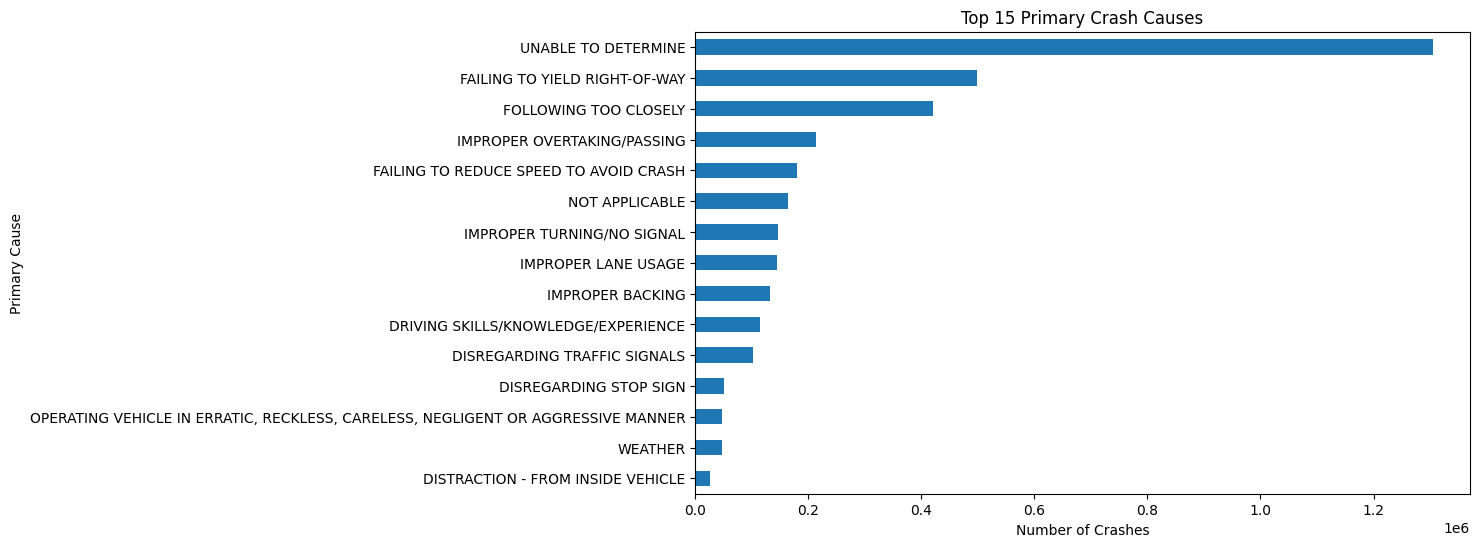

In [91]:
# standardizing categorical columns
# first we standardize the target column
cause_counts = data_model['prim_contributory_cause'].value_counts()

# Display top 15 causes
top_n = 15
plt.figure(figsize=(10,6))
cause_counts.head(top_n).plot(kind='barh')
plt.gca().invert_yaxis()  
plt.title(f"Top {top_n} Primary Crash Causes")
plt.xlabel("Number of Crashes")
plt.ylabel("Primary Cause")
plt.show()

In [92]:
# we remove unable to determine and not applicable because they wont help our predictions
data_model = data_model[~data_model['prim_contributory_cause'].isin([
    'UNABLE TO DETERMINE',
    'NOT APPLICABLE'
])]

In [93]:
# we map our target feature into simpler, smaller and more interpretable classes
cause_mapping = {
    # Driver behavior
    'DRIVING SKILLS/KNOWLEDGE/EXPERIENCE': 'Driver Behavior',
    'IMPROPER TURNING/NO SIGNAL': 'Driver Behavior',
    'IMPROPER OVERTAKING/PASSING': 'Driver Behavior',
    'FAILING TO YIELD RIGHT-OF-WAY': 'Driver Behavior',
    'FAILING TO REDUCE SPEED TO AVOID CRASH': 'Driver Behavior',
    'IMPROPER LANE USAGE': 'Driver Behavior',
    'FOLLOWING TOO CLOSELY': 'Driver Behavior',
    'IMPROPER BACKING': 'Driver Behavior',
    'OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER': 'Driver Behavior',
    'DRIVING ON WRONG SIDE/WRONG WAY': 'Driver Behavior',
    
    # Impairment
    'UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)': 'Impairment',
    'HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE)': 'Impairment',
    'PHYSICAL CONDITION OF DRIVER': 'Impairment',
    
    # Traffic control violations
    'DISREGARDING TRAFFIC SIGNALS': 'Traffic Control Violation',
    'DISREGARDING STOP SIGN': 'Traffic Control Violation',
    'TURNING RIGHT ON RED': 'Traffic Control Violation',
    'DISREGARDING ROAD MARKINGS': 'Traffic Control Violation',
    'DISREGARDING OTHER TRAFFIC SIGNS': 'Traffic Control Violation',
    'DISREGARDING YIELD SIGN': 'Traffic Control Violation',
    'PASSING STOPPED SCHOOL BUS': 'Traffic Control Violation',
    'OBSTRUCTED CROSSWALKS': 'Traffic Control Violation',
    'BICYCLE ADVANCING LEGALLY ON RED LIGHT': 'Traffic Control Violation',
    'MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT': 'Traffic Control Violation',
    
    # Environment
    'WEATHER': 'Environmental/Road Conditions',
    'VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)': 'Environmental/Road Conditions',
    'ROAD CONSTRUCTION/MAINTENANCE': 'Environmental/Road Conditions',
    'ROAD ENGINEERING/SURFACE/MARKING DEFECTS': 'Environmental/Road Conditions',
    'EVASIVE ACTION DUE TO ANIMAL, OBJECT, NONMOTORIST': 'Environmental/Road Conditions',
    
    # Vehicle
    'EQUIPMENT - VEHICLE CONDITION': 'Vehicle Issues',
    
    # Distraction
    'DISTRACTION - FROM INSIDE VEHICLE': 'Distraction',
    'DISTRACTION - FROM OUTSIDE VEHICLE': 'Distraction',
    'DISTRACTION - OTHER ELECTRONIC DEVICE (NAVIGATION DEVICE, DVD PLAYER, ETC.)': 'Distraction',
    'TEXTING': 'Distraction',
    'CELL PHONE USE OTHER THAN TEXTING': 'Distraction',
    
    # Other
    'ANIMAL': 'Other',
    'RELATED TO BUS STOP': 'Other'
}
data_model['cause_group'] = data_model['prim_contributory_cause'].map(cause_mapping)

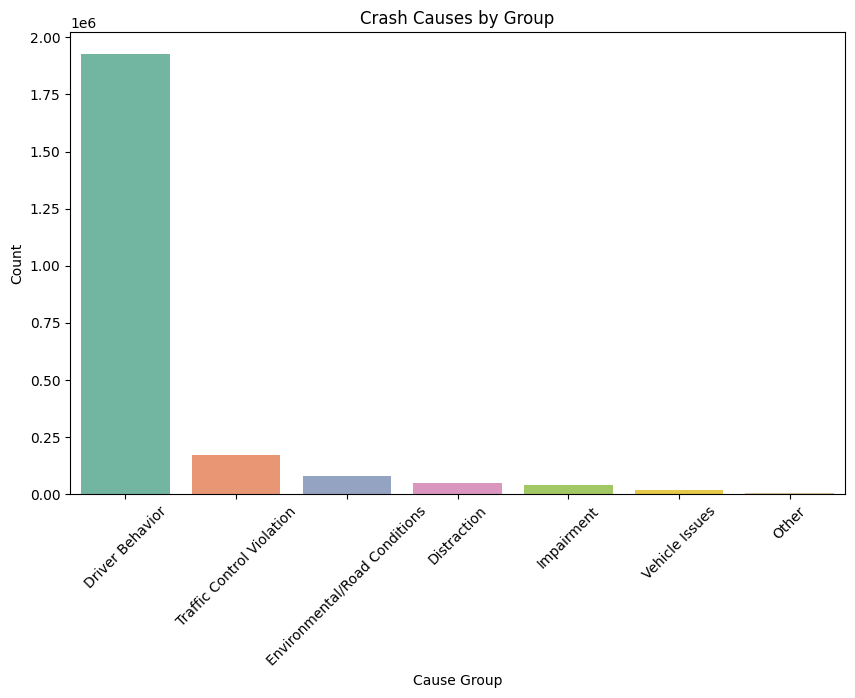

In [94]:
# Plot grouped categories
plt.figure(figsize=(10,6))
sns.countplot(
    x=data_model['cause_group'],
    order=data_model['cause_group'].value_counts().index,
    palette="Set2"
)
plt.title("Crash Causes by Group")
plt.xlabel("Cause Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [95]:
data_model.isnull().sum()

crash_date_x                   0
posted_speed_limit             0
traffic_control_device         0
device_condition               0
weather_condition              0
lighting_condition             0
first_crash_type               0
trafficway_type                0
alignment                      0
roadway_surface_cond           0
road_defect                    0
crash_type                     0
prim_contributory_cause        0
street_direction               0
num_units                      0
crash_hour                     0
crash_day_of_week              0
crash_month                    0
latitude                       0
longitude                      0
location                       0
unit_type                      0
vehicle_defect                 0
vehicle_type                   0
travel_direction               0
maneuver                       0
occupant_cnt                   0
sex                            0
driver_action                  0
driver_vision                  0
physical_c

In [96]:
data_model['cause_group'] = data_model['cause_group'].dropna

In [97]:
data_model.drop('prim_contributory_cause', axis=1, inplace=True)

### Identifying Speed Limits at Crash Locations

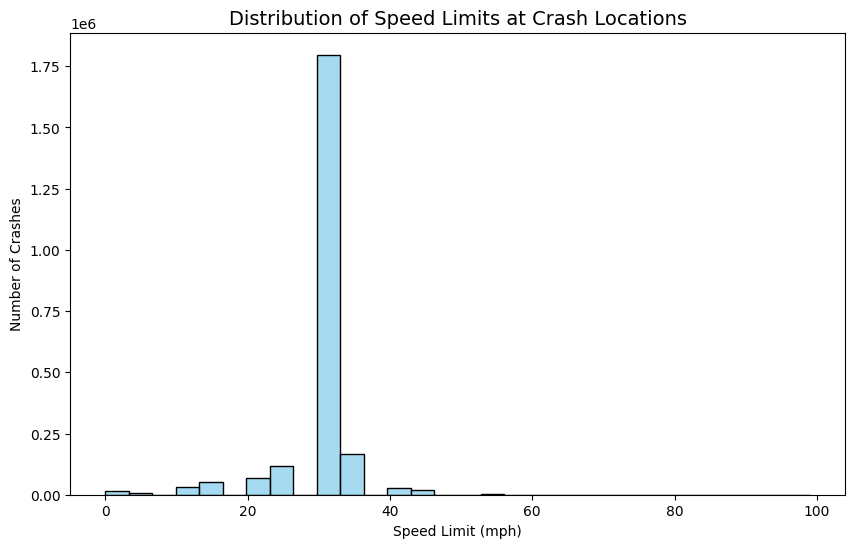

In [99]:
# hsitogram to visualize speed data
plt.figure(figsize=(10,6))
sns.histplot(data_model['posted_speed_limit'], bins=30, kde=False, color='skyblue', edgecolor='black')
plt.title("Distribution of Speed Limits at Crash Locations", fontsize=14)
plt.xlabel("Speed Limit (mph)")
plt.ylabel("Number of Crashes")
plt.show()

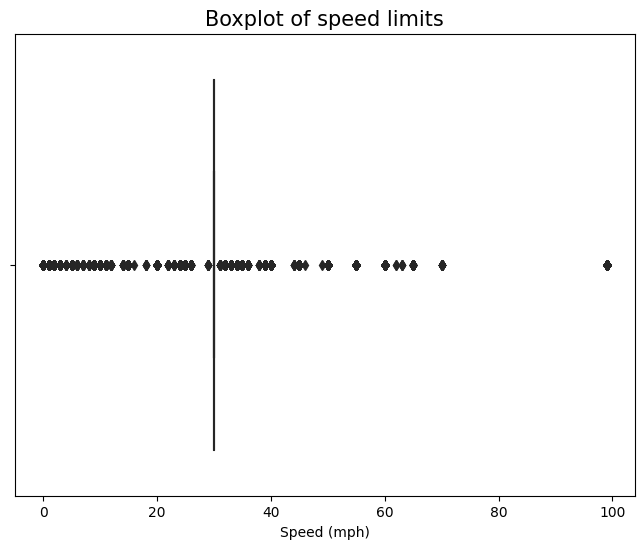

In [100]:
# box plot to  check outliers in speedlimit data
plt.figure(figsize=(8,6))
sns.boxplot(x=data['posted_speed_limit'], color='green')
plt.title('Boxplot of speed limits', fontsize=15)
plt.xlabel('Speed (mph)')
plt.show()

**Observations**
* Crashes are less frequent at highway speeds (55–70 mph), likely because highways have fewer intersections and controlled access
* The majority of crashes occur at 20–40 mph, which matches real-world expectations (residential and arterial roads).

### Traffic control devices

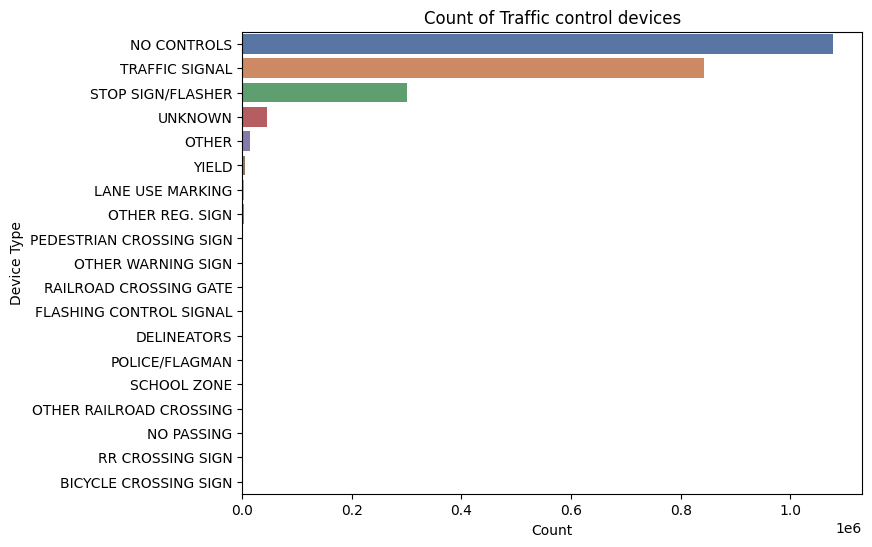

In [103]:
# create a barplot to show the traffic control signal at point of crash
device_count = data_model['traffic_control_device'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(y=device_count.index, x=device_count.values, palette='deep')
plt.title('Count of Traffic control devices')
plt.ylabel('Device Type')
plt.xlabel('Count')
plt.show()

**Observation**
* “No Controls” is the leading category, meaning many crashes occur at uncontrolled intersections or roadway segments without traffic control.
* “Traffic Signal” closely follows, highlighting that even at signalized intersections crashes are common (likely due to violations such as running red lights or misjudging signals).
* “Stop Sign/Flasher” also contributes significantly, consistent with the risk of crashes at stop-controlled intersections.

### Device Condition 

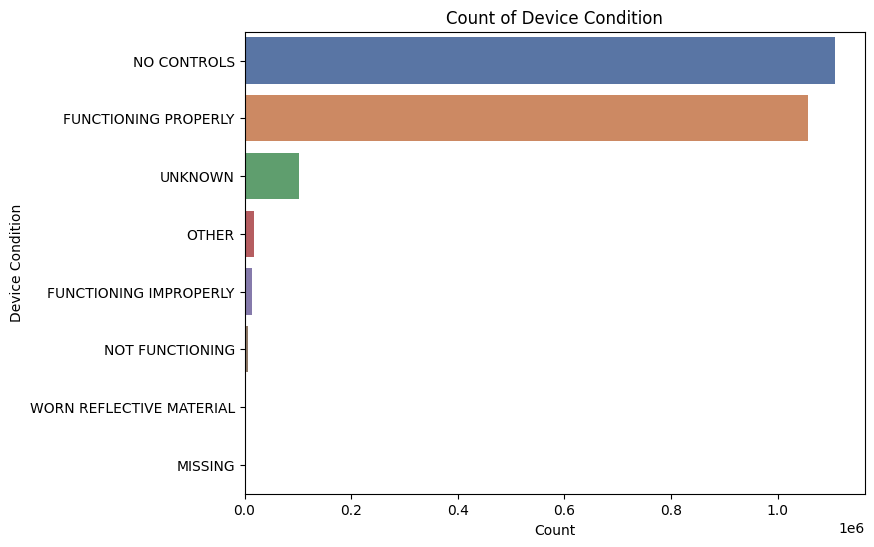

In [106]:
# barplot of device condition at point of crash
condition_count = data_model['device_condition'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(y=condition_count.index, x=condition_count.values, palette='deep')
plt.title('Count of Device Condition')
plt.xlabel('Count')
plt.ylabel('Device Condition')
plt.show()

**Observation**
* Most accidents happen on no controll devices and as obvious we expect most accidents to be captured with properly functioning devices

### Weather Condition

In [109]:
# First we need to map the weather conditions to a much simpler reading
# This is to reduce cardinality
weather_mapping = {
    'CLEAR': 'Clear',
    'RAIN': 'Rain',
    'SNOW': 'Snow',
    'CLOUDY/OVERCAST': 'Cloudy/Overcast',
    'UNKNOWN': 'Unknown',
    'OTHER': 'Other',
    'FOG/SMOKE/HAZE': 'Other',
    'FREEZING RAIN/DRIZZLE': 'Other',
    'BLOWING SAND, SOIL, DIRT': 'Other',
    'SLEET/HAIL': 'Other',
    'SEVERE CROSS WIND GATE': 'Other',
    'BLOWING SNOW': 'Other'
}
data_model['weather_condition'] = data_model['weather_condition'].map(weather_mapping)

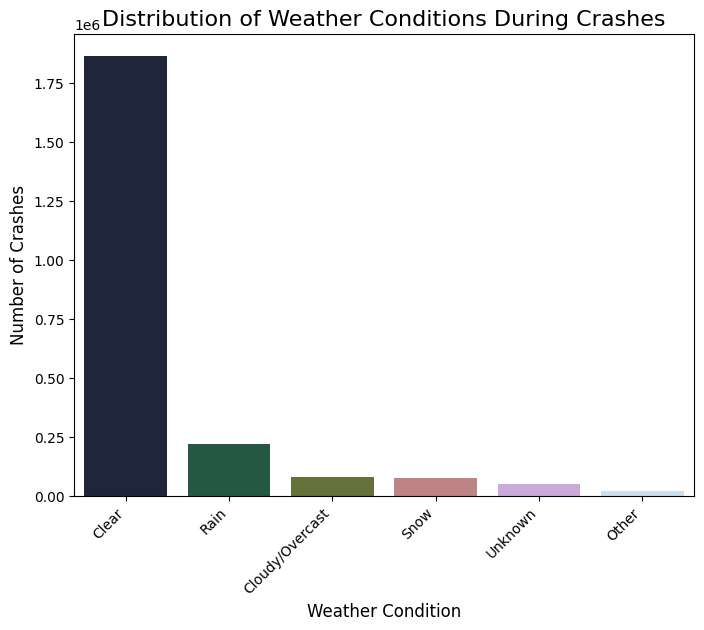

In [110]:
# plot barplot
weather_count = data_model['weather_condition'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(x=weather_count.index, y=weather_count.values, palette='cubehelix')
plt.title("Distribution of Weather Conditions During Crashes", fontsize=16)
plt.xlabel("Weather Condition", fontsize=12)
plt.ylabel("Number of Crashes", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.show()

**Observation**
* Most crashes occur during Clear weather, which aligns with expectations since most driving happens in normal conditions.
* Rain, Snow, and Cloudy/Overcast are the next most common conditions, reflecting environmental risks like reduced visibility and slippery roads.

In [112]:
data_model.columns

Index(['crash_date_x', 'posted_speed_limit', 'traffic_control_device',
       'device_condition', 'weather_condition', 'lighting_condition',
       'first_crash_type', 'trafficway_type', 'alignment',
       'roadway_surface_cond', 'road_defect', 'crash_type', 'street_direction',
       'num_units', 'crash_hour', 'crash_day_of_week', 'crash_month',
       'latitude', 'longitude', 'location', 'unit_type', 'vehicle_defect',
       'vehicle_type', 'travel_direction', 'maneuver', 'occupant_cnt', 'sex',
       'driver_action', 'driver_vision', 'physical_condition', 'bac_result',
       'cause_group'],
      dtype='object')

### Lighting Conditions

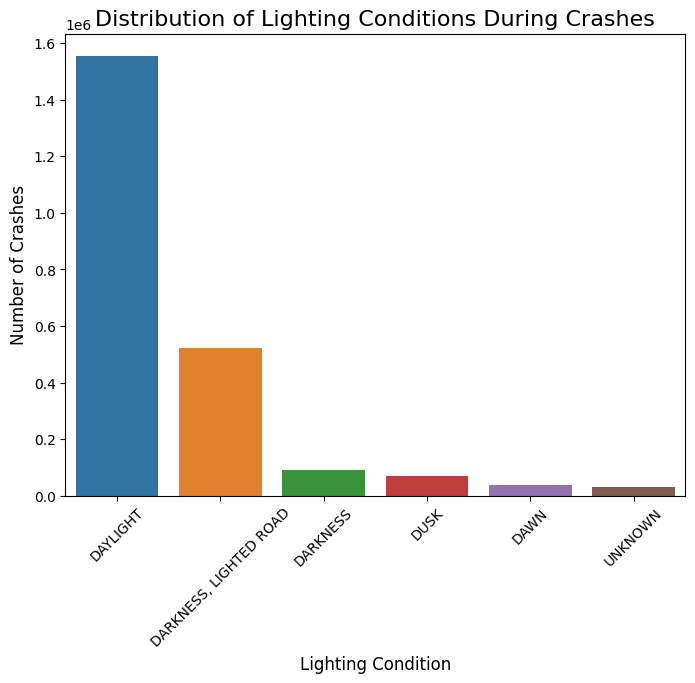

In [114]:
# plot countplot
plt.figure(figsize=(8,6))
sns.countplot(data=data_model, x='lighting_condition', order=data_model['lighting_condition'].value_counts().index)
plt.title("Distribution of Lighting Conditions During Crashes", fontsize=16)
plt.xlabel("Lighting Condition", fontsize=12)
plt.ylabel("Number of Crashes", fontsize=12)
plt.xticks(rotation=45)
plt.show()        

**Observation**
* Daylight leads by a wide margin, meaning most crashes occur when visibility is good.
* This is followed by Darkness with street lighting, indicating crashes are also frequent at night in well-lit areas.

In [116]:
data_model['first_crash_type'].unique()

array(['SIDESWIPE OPPOSITE DIRECTION', 'OTHER OBJECT', 'HEAD ON',
       'FIXED OBJECT', 'SIDESWIPE SAME DIRECTION', 'REAR END', 'TURNING',
       'PARKED MOTOR VEHICLE', 'PEDESTRIAN', 'PEDALCYCLIST', 'ANGLE',
       'REAR TO SIDE', 'REAR TO REAR', 'REAR TO FRONT', 'ANIMAL',
       'OTHER NONCOLLISION', 'OVERTURNED', 'TRAIN'], dtype=object)

### First Crash Type

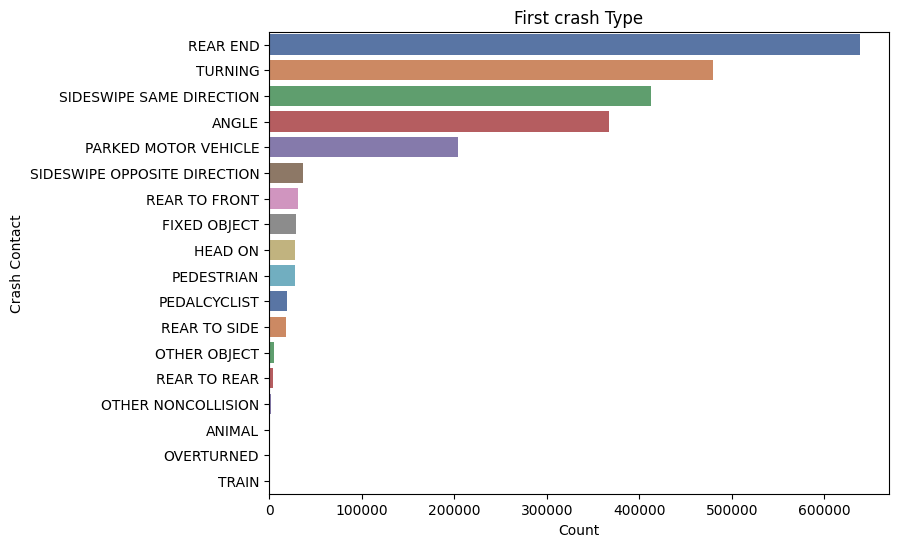

In [118]:
# plot countplot
crash_count = data_model['first_crash_type'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(y=crash_count.index, x=crash_count.values, palette='deep')
plt.title('First crash Type')
plt.ylabel('Crash Contact')
plt.xlabel('Count')
plt.show()

**Observation**
* The categories REAR END, TURNING, and SIDESWIPE SAME DIRECTION are by far the most frequent, each accounting for hundreds of thousands of incidents.

### Trafficway Type

In [121]:
# map trafficway type 
trafficway_mapping = {
    "ONE-WAY": "Single/Dual Carriageways",
    "NOT DIVIDED": "Single/Dual Carriageways",
    "DIVIDED - W/MEDIAN (NOT RAISED)": "Single/Dual Carriageways",
    "DIVIDED - W/MEDIAN BARRIER": "Single/Dual Carriageways",
    "CENTER TURN LANE": "Single/Dual Carriageways",

    "FOUR WAY": "Intersections",
    "T-INTERSECTION": "Intersections",
    "Y-INTERSECTION": "Intersections",
    "L-INTERSECTION": "Intersections",
    "FIVE POINT, OR MORE": "Intersections",
    "ROUNDABOUT": "Intersections",
    "UNKNOWN INTERSECTION TYPE": "Intersections",

    "PARKING LOT": "Non-standard/Access Roads",
    "DRIVEWAY": "Non-standard/Access Roads",
    "RAMP": "Non-standard/Access Roads",
    "ALLEY": "Non-standard/Access Roads",
    "TRAFFIC ROUTE": "Non-standard/Access Roads",

    "OTHER": "Other/Unknown",
    "UNKNOWN": "Other/Unknown",
    "NOT REPORTED": "Other/Unknown"
}

data_model["trafficway_type"] = data_model["trafficway_type"].map(trafficway_mapping)

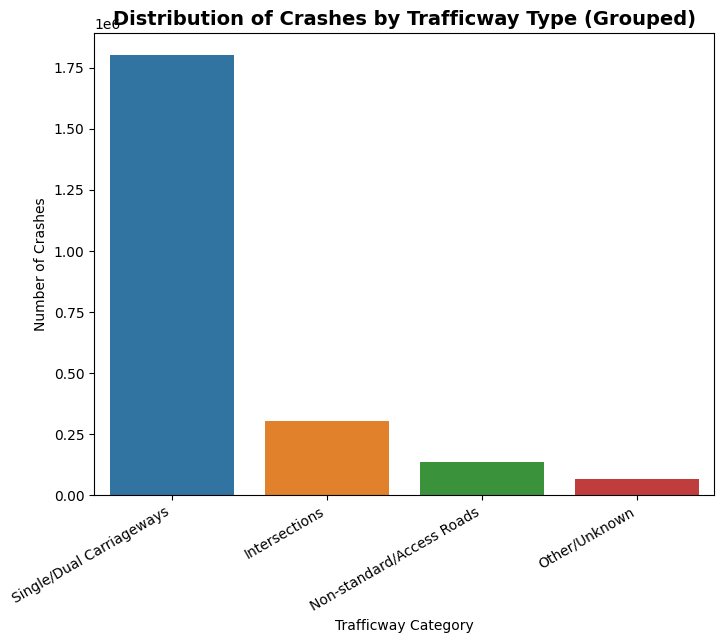

In [122]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=data_model, 
    x="trafficway_type", 
    order=data_model["trafficway_type"].value_counts().index,
)

plt.title("Distribution of Crashes by Trafficway Type (Grouped)", fontsize=14, weight='bold')
plt.xlabel("Trafficway Category")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=30, ha="right")
plt.show()

**Observations**
* Overall, most crashes happen on main carriageways (single/dual), followed by intersections, while access roads contribute less. This reflects real-world driving risk exposure.

### Alignment

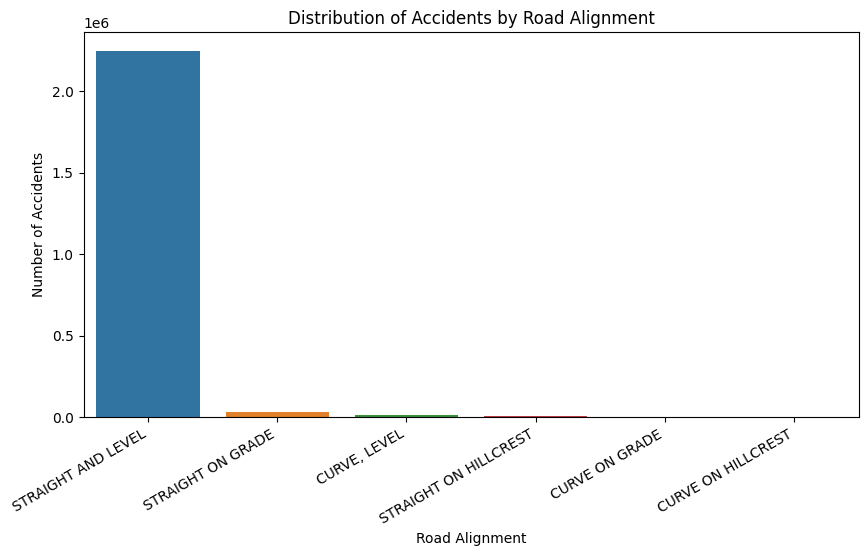

In [125]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=data_model,
    x='alignment',
    order=data_model['alignment'].value_counts().index,
)
plt.title("Distribution of Accidents by Road Alignment")
plt.xlabel("Road Alignment")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=30, ha="right")
plt.show()

**Observation**
* The distribution shows that "Straight and Level" roads dominate, followed by "Straight on Grade" and "Curve, Level". This pattern is logical since Chicago’s road network is largely flat and straight, reducing the proportion of curved or hilly alignments.
* If these categories prove weak predictors during modeling, we may later simplify into “Straight” vs “Curved” to improve interpretability and reduce noise.

## Road Surface


In [128]:
roadway_mapping = {
    'DRY': 'DRY',
    'WET': 'WET',
    'SAND': 'OTHER',
    'MUD': 'OTHER',
    'DIRT': 'OTHER',
    'SNOW OR SLUSH': 'OTHER',
    'ICE': 'OTHER',
    'OTHER': 'OTHER',
    'UNKNOWN': 'OTHER' 
    # Assuming 'UNKNOWN' should also be grouped into 'OTHER' for simplicity
}
data_model['roadway_surface_cond'] = data_model['roadway_surface_cond'].map(roadway_mapping)

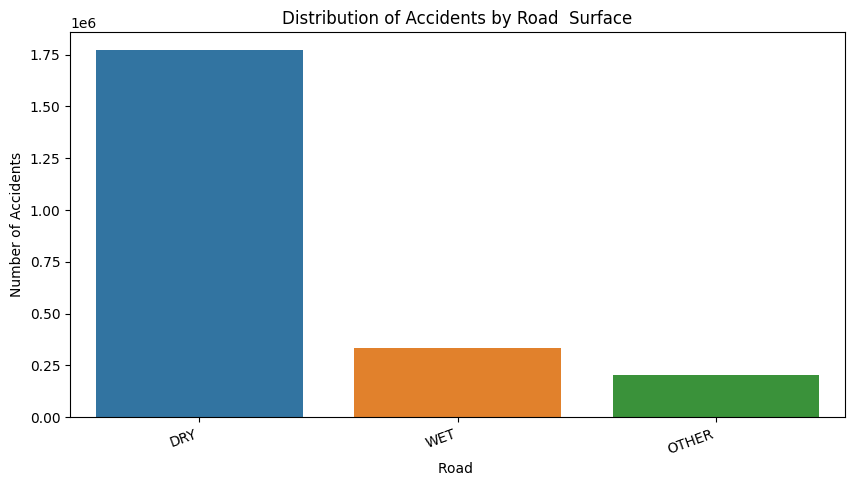

In [129]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=data_model,
    x='roadway_surface_cond',
    order=data_model['roadway_surface_cond'].value_counts().index,
)
plt.title("Distribution of Accidents by Road  Surface")
plt.xlabel("Road ")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=20, ha="right")
plt.show()

**Observation**
* The majority of crashes occurred on Dry surfaces, followed by Wet surfaces. Other road surfaces are sand, ice, snow or slush

### Road Defect

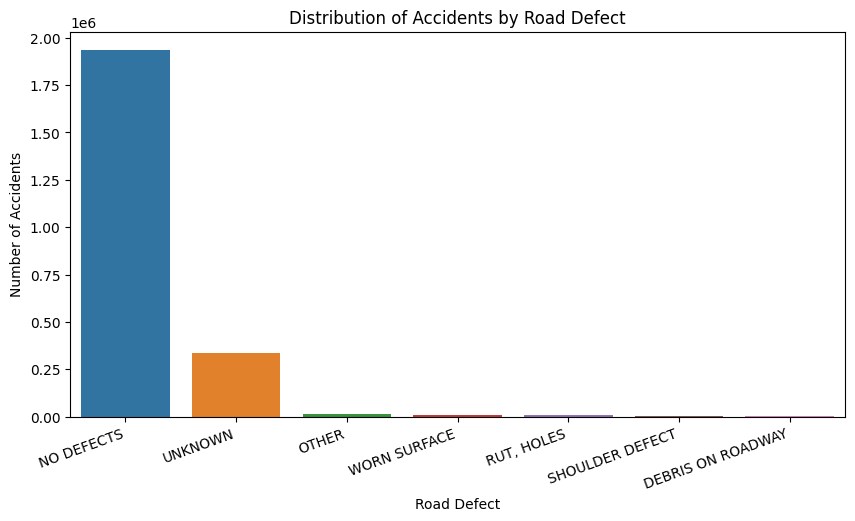

In [132]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=data_model,
    x='road_defect',
    order=data_model['road_defect'].value_counts().index,
)
plt.title("Distribution of Accidents by Road Defect")
plt.xlabel("Road Defect")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=20, ha="right")
plt.show()

In [133]:
road_defect_mapping = {
    'NO DEFECTS': 'NO DEFECTS',
    'UNKNOWN': 'UNKNOWN',
    'OTHER': 'OTHER DEFECTS',
    'WORN SURFACE': 'OTHER DEFECTS',
    'RUT, HOLES': 'OTHER DEFECTS',
    'SHOULDER DEFECT': 'OTHER DEFECTS',
    'DEBRIS ON ROADWAY': 'OTHER DEFECTS'
}
data_model['road_defect'] = data_model['road_defect'].map(road_defect_mapping)

**Observation**
* The majority of crashes occurred on roads with No Defects, followed by cases recorded as Unknown.
* Minor contributions come from Worn Surface, Ruts/Holes, Shoulder Defects, and Debris on Roadway.

### Time of Occurence

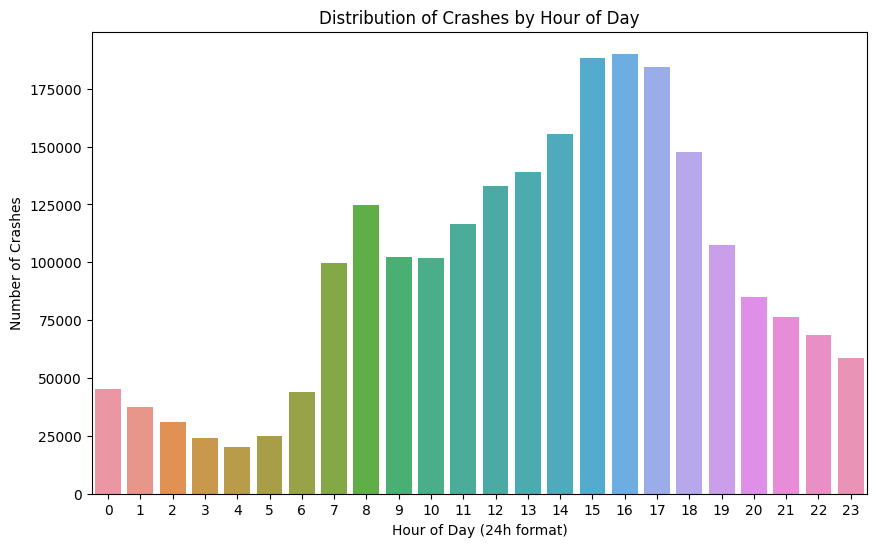

In [136]:
plt.figure(figsize=(10,6))
sns.countplot(x="crash_hour", data=data_model, order=sorted(data_model['crash_hour'].unique()))
plt.title("Distribution of Crashes by Hour of Day")
plt.xlabel("Hour of Day (24h format)")
plt.ylabel("Number of Crashes")
plt.show()

**Observation**
* The distribution of crashes by hour shows clear time-of-day patterns.
* This observation highlights that traffic volume and commuting patterns are strong contributors to crash frequency, making crash_hour a valuable feature for modeling.

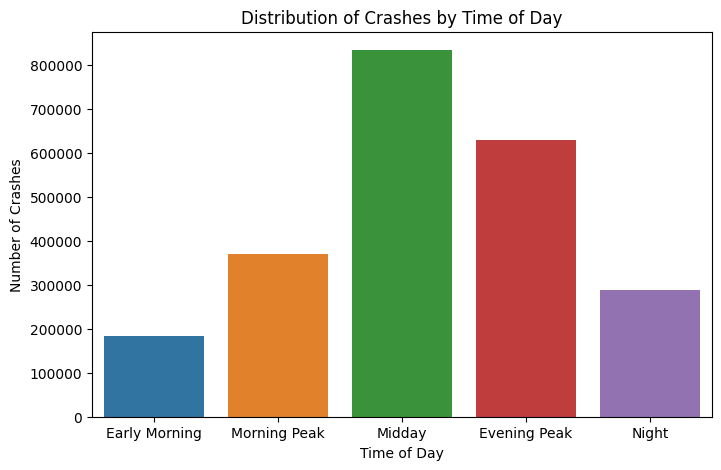

In [138]:
def map_time_of_day(hour):
    if 0 <= hour <= 5:
        return 'Early Morning'
    elif 6 <= hour <= 9:
        return 'Morning Peak'
    elif 10 <= hour <= 15:
        return 'Midday'
    elif 16 <= hour <= 19:
        return 'Evening Peak'
    else:
        return 'Night'

data_model['time_of_day'] = data_model['crash_hour'].apply(map_time_of_day)

plt.figure(figsize=(8,5))
sns.countplot(data=data_model, x='time_of_day', order=['Early Morning','Morning Peak','Midday','Evening Peak','Night'])
plt.title("Distribution of Crashes by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Crashes")
plt.show()

**Observation**
* This feature provides a more interpretable grouping of crash times and could improve the model’s ability to capture time-based risk patterns.
* Midday has the highest number of crashes, reflecting heavy daytime traffic and school/work-related movements. Morning Peak and Evening Peak also show elevated crash counts, consistent with rush-hour traffic congestion.

### Which month records the highest accidents

In [141]:
month_map = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}

data_model['crash_month'] = data_model['crash_month'].map(month_map)

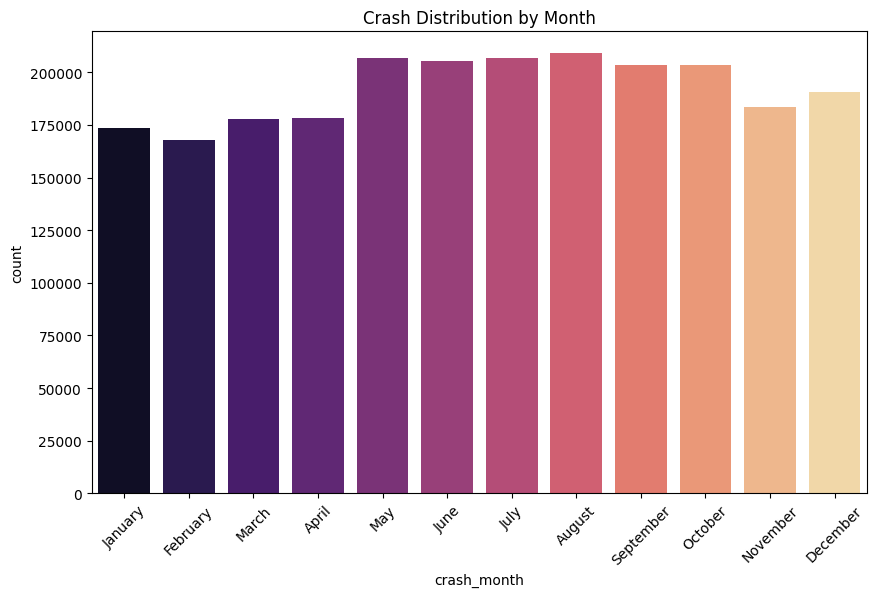

In [142]:
plt.figure(figsize=(10,6))
sns.countplot(x="crash_month", data=data_model, order=[
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
], palette='magma')
plt.title("Crash Distribution by Month")
plt.xticks(rotation=45)
plt.show()

**Observations**
* Crashes are distributed across all 12 months.
* Summer months (June, July, August, September) record the highest number of crashes, likely due to higher travel activity, events, and favorable weather encouraging road usage.

### Which day do most crushes occur?

In [145]:
day_map = {
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday',
    7: 'Sunday'
}

data_model['crash_day_of_week'] = data_model['crash_day_of_week'].map(day_map)

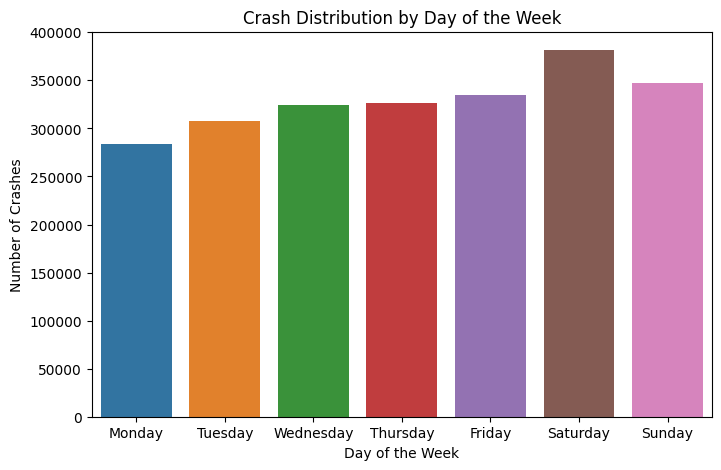

In [146]:
plt.figure(figsize=(8,5))
sns.countplot(data=data_model, x='crash_day_of_week',
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Crash Distribution by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Crashes")
plt.show()

**Observation**
* Saturday records the highest number of crashes, making weekends a particularly high-risk period. Overall, crashes tend to increase toward the weekend and dip at the start of the week.

### Unit type

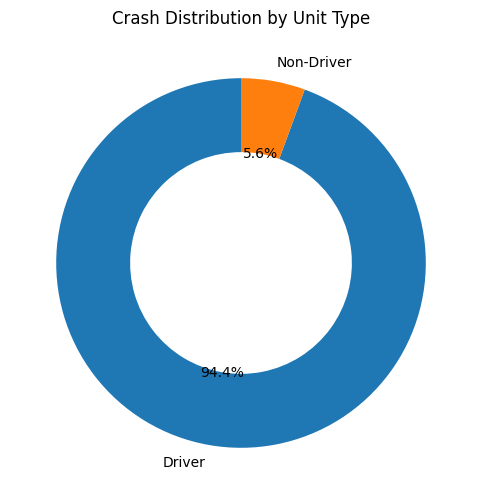

In [149]:
data_model['unit_type'] = data_model['unit_type'].apply(
    lambda x: 'Driver' if x == 'DRIVER' else 'Non-Driver'
)
counts = data_model['unit_type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'width':0.4})
plt.title("Crash Distribution by Unit Type")
plt.show()

**Observation**
* I grouped the unit_type_1 column into Driver (active participant) and Non-Driver (parked, driverless, disabled, non-contact vehicles) to simplify the feature for modeling. Driver dominates the chart, indicating that most crashes involve actively driven vehicles.

### Type of Vehicle  

In [152]:
data_model.columns

Index(['crash_date_x', 'posted_speed_limit', 'traffic_control_device',
       'device_condition', 'weather_condition', 'lighting_condition',
       'first_crash_type', 'trafficway_type', 'alignment',
       'roadway_surface_cond', 'road_defect', 'crash_type', 'street_direction',
       'num_units', 'crash_hour', 'crash_day_of_week', 'crash_month',
       'latitude', 'longitude', 'location', 'unit_type', 'vehicle_defect',
       'vehicle_type', 'travel_direction', 'maneuver', 'occupant_cnt', 'sex',
       'driver_action', 'driver_vision', 'physical_condition', 'bac_result',
       'cause_group', 'time_of_day'],
      dtype='object')

In [153]:
vehicle_mapping = {
    'PASSENGER': 'Passenger Vehicle',
    'SPORT UTILITY VEHICLE (SUV)': 'Passenger Vehicle',
    'VAN/MINI-VAN': 'Passenger Vehicle',
    'PICKUP': 'LightTruck-Pickup',
    'TRACTOR W/ SEMI-TRAILER': 'Heavy-Truck-Trailer',
    'TRACTOR W/O SEMI-TRAILER': 'Heavy-Truck-Trailer',
    'TRUCK - SINGLE UNIT': 'Heavy-Truck-Trailer',
    'SINGLE UNIT TRUCK WITH TRAILER': 'Heavy-Truck-Trailer',
    'OTHER VEHICLE WITH TRAILER': 'Heavy-Truck-Trailer',
    'BUS OVER 15 PASS.': 'Bus',
    'BUS UP TO 15 PASS.': 'Bus',
    'MOTORCYCLE (OVER 150CC)': 'Motorcycle-Two-Wheeler',
    '3-WHEELED MOTORCYCLE (2 REAR WHEELS)': 'Motorcycle-Two-Wheeler',
    'MOPED OR MOTORIZED BICYCLE': 'Motorcycle-Two-Wheeler',
    'MOTOR DRIVEN CYCLE': 'Motorcycle-Two-Wheeler',
    'AUTOCYCLE': 'Motorcycle-Two-Wheeler',
    'ALL-TERRAIN VEHICLE (ATV)': 'Recreational-Special',
    'RECREATIONAL OFF-HIGHWAY VEHICLE (ROV)': 'Recreational-Special',
    'FARM EQUIPMENT': 'Recreational-Special',
    'OTHER': 'Other',
    'UNKNOWN/NA': 'Other'
}

data_model['vehicle_type'] = data_model['vehicle_type'].map(vehicle_mapping)

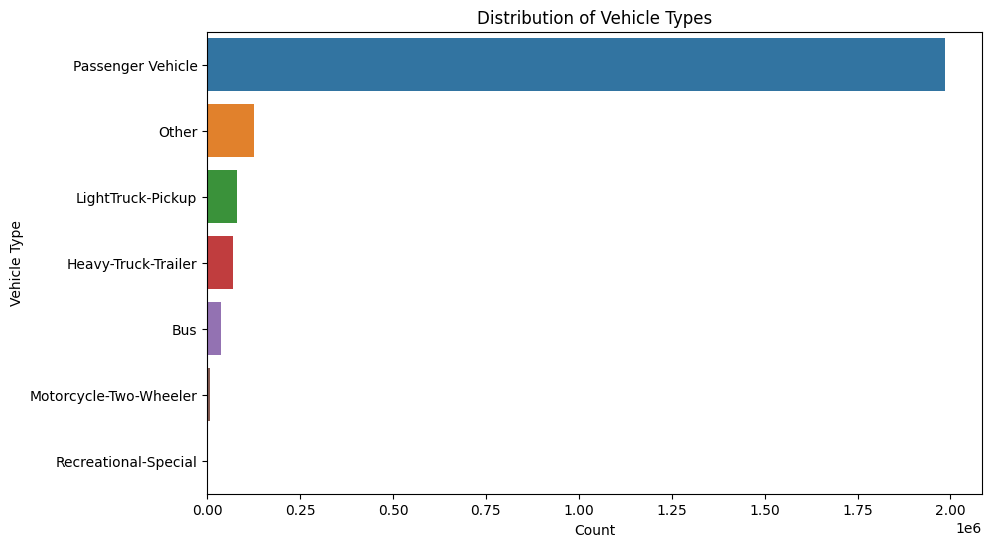

In [154]:
plt.figure(figsize=(10,6))
sns.countplot(y=data_model['vehicle_type'], order=data_model['vehicle_type'].value_counts().index)
plt.title("Distribution of Vehicle Types")
plt.xlabel("Count")
plt.ylabel("Vehicle Type")
plt.show()

**Observations**
*  The majority of accidents involve passenger vehicles, followed by pickups and heavy trucks. This aligns with expectations, given their higher share on the roads. However, even though buses, motorcycles, and specialized vehicles are less frequent, they may represent higher-severity accidents, making them important from a safety and insurance perspective.

### Vehicle maneuver during accident

In [157]:
maneuver_mapping = {
    "STRAIGHT AHEAD": "Straight Ahead",
    "TURNING LEFT": "Turning Left",
    "TURNING RIGHT": "Turning Right",
    "U-TURN": "U-Turn",
    "CHANGING LANES": "Changing Lanes",
    "MERGING": "Merging",
    "NEGOTIATING A CURVE": "Curve/Skid",
    "SKIDDING/CONTROL LOSS": "Curve/Skid",
    "DRIVING WRONG WAY": "Wrong Way",
    "PARKED": "Parking-related",
    "PARKED IN TRAFFIC LANE": "Parking-related",
    "ENTERING TRAFFIC LANE FROM PARKING": "Parking-related",
    "LEAVING TRAFFIC LANE TO PARK": "Parking-related",
    "STARTING IN TRAFFIC": "Parking-related",
    "SLOW/STOP IN TRAFFIC": "Slowing/Stopping",
    "SLOW/STOP - LEFT TURN": "Slowing/Stopping",
    "SLOW/STOP - RIGHT TURN": "Slowing/Stopping",
    "SLOW/STOP - LOAD/UNLOAD": "Slowing/Stopping",
    "UNKNOWN/NA": "Other/Unknown",
    "OTHER": "Other/Unknown",
    "DISABLED": "Other/Unknown",
    "DRIVERLESS": "Other/Unknown",
    "AVOIDING VEHICLES/OBJECTS": "Other/Unknown",
    "TURNING ON RED": "Other/Unknown",
    "ENTER FROM DRIVE/ALLEY": "Other/Unknown",
    "DIVERGING": "Other/Unknown",
    "BACKING": "Other/Unknown"
}
data_model["maneuver"] = data_model["maneuver"].map(maneuver_mapping)


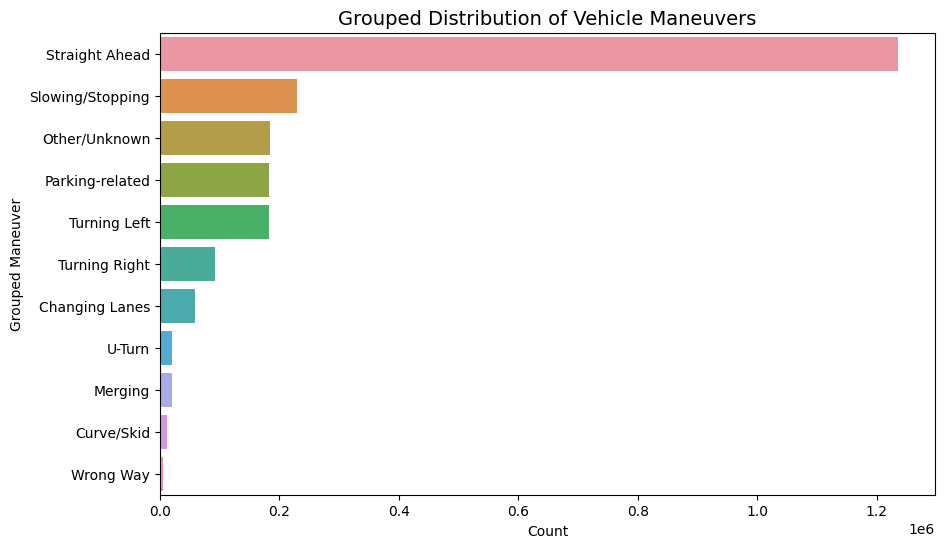

In [158]:
plt.figure(figsize=(10,6))
sns.countplot(data=data_model, y="maneuver", order=data_model["maneuver"].value_counts().index)
plt.title("Grouped Distribution of Vehicle Maneuvers", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Grouped Maneuver")
plt.show()

**Observation**
* Straight Ahead maneuvers dominate the dataset — by far the most common scenario for accidents. Parking-related maneuvers (parked, entering/leaving traffic, starting in traffic) come second.

### Vehicle Defect

In [161]:
driver_action_mapping = {
    # Distraction/Inattention
    'CELL PHONE USE OTHER THAN TEXTING': 'DISTRACTION/INATTENTION',
    'TEXTING': 'DISTRACTION/INATTENTION',
    'DISREGARDED CONTROL DEVICES': 'DISTRACTION/INATTENTION',
    'NONE': 'UNKNOWN/NONE/OTHER',  # Often 'NONE' means driver was not at fault or action is unknown
    'UNKNOWN': 'UNKNOWN/NONE/OTHER',

    # Aggressive/Reckless Driving
    'TOO FAST FOR CONDITIONS': 'AGGRESSIVE/RECKLESS',
    'EVADING POLICE VEHICLE': 'AGGRESSIVE/RECKLESS',
    'OVERCORRECTED': 'AGGRESSIVE/RECKLESS',  # Often a consequence of reckless speed or maneuver

    # Improper Maneuvers/Violations
    'FOLLOWED TOO CLOSELY': 'IMPROPER MANEUVER/VIOLATION',
    'FAILED TO YIELD': 'IMPROPER MANEUVER/VIOLATION',
    'WRONG WAY/SIDE': 'IMPROPER MANEUVER/VIOLATION',
    'IMPROPER LANE CHANGE': 'IMPROPER MANEUVER/VIOLATION',
    'IMPROPER TURN': 'IMPROPER MANEUVER/VIOLATION',
    'IMPROPER BACKING': 'IMPROPER MANEUVER/VIOLATION',
    'IMPROPER PASSING': 'IMPROPER MANEUVER/VIOLATION',
    'IMPROPER PARKING': 'IMPROPER MANEUVER/VIOLATION',
    'STOPPED SCHOOL BUS': 'IMPROPER MANEUVER/VIOLATION',
    
    # Administrative/Other
    'LICENSE RESTRICTIONS': 'ADMINISTRATIVE/OTHER',
    'EMERGENCY VEHICLE ON CALL': 'ADMINISTRATIVE/OTHER', # Specialized action, not necessarily fault
    'OTHER': 'UNKNOWN/NONE/OTHER'
}
data_model['driver_action'] = data_model['driver_action'].map(driver_action_mapping)

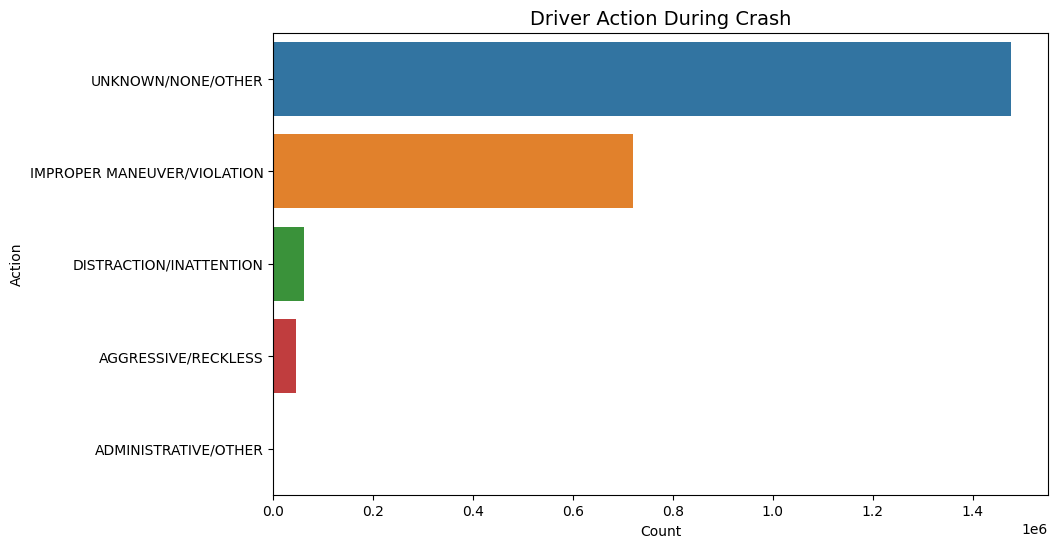

In [162]:
plt.figure(figsize=(10,6))
sns.countplot(data=data_model, y='driver_action', order=data_model['driver_action'].value_counts().index)
plt.title("Driver Action During Crash", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Action")
plt.show()

**Observation**
* The category 'UNKNOWN/NONE/OTHER' is the most frequent, with a count exceeding 1.4 million incidents. This bar is significantly longer than all other categories combined. The second most common category is 'IMPROPER MANEUVER/VIOLATION', which accounts for approximately 650,000 incidents.
* Categories related to specific driver faults, such as 'DISTRACTION/INATTENTION' and 'AGGRESSIVE/RECKLESS', are reported at a much lower frequency (both well under 200,000).

### Crash Distribution by Sex

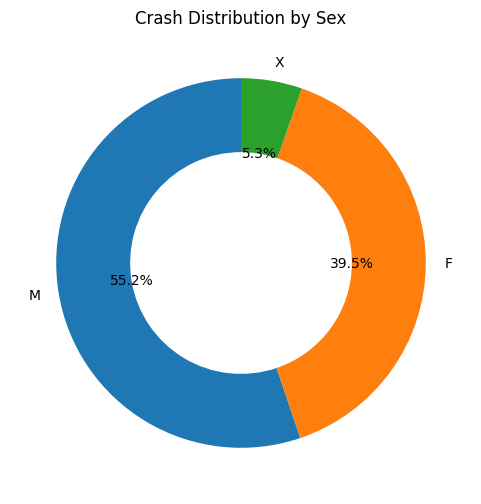

In [165]:
counts = data_model['sex'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'width':0.4})
plt.title("Crash Distribution by Sex")
plt.show()

### Number of units involved in Crashes

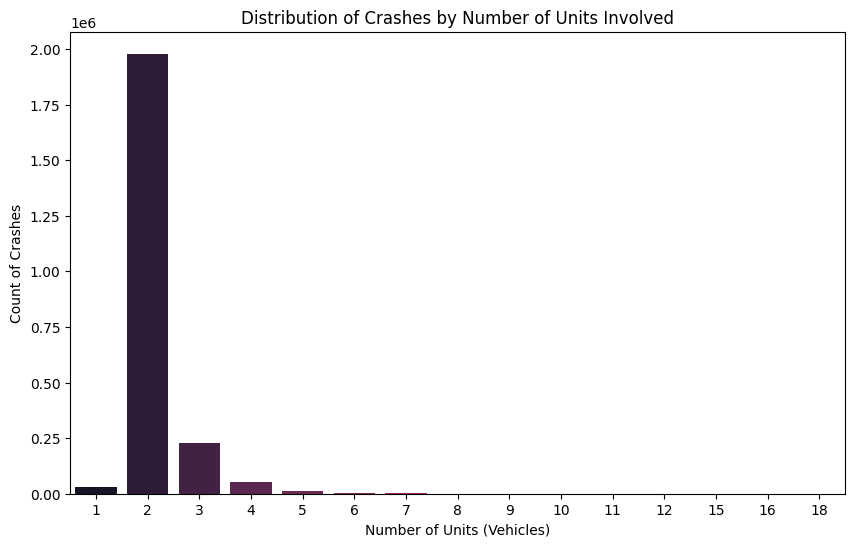

In [167]:
plt.figure(figsize=(10, 6))
# The countplot automatically calculates the frequencies of the x-variable
sns.countplot(data=data_model, x='num_units', palette='rocket')
plt.title("Distribution of Crashes by Number of Units Involved")
plt.xlabel("Number of Units (Vehicles)")
plt.ylabel("Count of Crashes")
plt.show()

In [ ]:
# copy and drop columns that wont be used in modeling
col_todrop = ['street_direction','longitude','latitude', 'occupant_cnt','bac_result','physical_condition', 'driver_vision',
              'driver_action','vehicle_defect','travel_direction','location','crash_hour','crash_date_x','crash_type', 
              'street_direction','num_units']

model = data_model.copy(deep=True)

model.drop(columns=col_todrop, axis=1, inplace=True)